# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of four synthetic data generation models:
1. **CTGAN** - Conditional Tabular GAN
2. **CopulaGAN** - GAN-based with copula modeling
3. **Gaussian Copula** - Statistical copula-based approach
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


## Data Loading and Setup


In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
  
# data (as pandas dataframes) 
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets 
  
# metadata 
print(cdc_diabetes_health_indicators.metadata) 
  
# variable information 
print(cdc_diabetes_health_indicators.variables) 

{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

In [5]:
import pandas as pd

df = pd.concat([X, y], axis=1)
df.head(10)

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0
5,1,1,1,25,1,0,0,1,1,1,...,0,2,0,2,0,1,10,6,8,0
6,1,0,1,30,1,0,0,0,0,0,...,0,3,0,14,0,0,9,6,7,0
7,1,1,1,25,1,0,0,1,0,1,...,0,3,0,0,1,0,11,4,4,0
8,1,1,1,30,1,0,1,0,1,1,...,0,5,30,30,1,0,9,5,1,1
9,0,0,1,24,0,0,0,0,0,1,...,0,2,0,0,0,1,8,4,3,0


In [6]:
# for quick computaiton we are considering first 5000 sample 

data = df.sample(n=5000, random_state=42)

# Generating synthetic data

In [7]:
# Import SDV libraries
import sdv
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)


from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer
)
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

# Number of synthetic rows to generate per model
n_samples = 10000

# Define models in one place
models = {
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata)
}

# Store outputs
synthetic_datasets = {}
diagnostic_reports = {}
quality_reports = {}
summary = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(data)

    synthetic_data = model.sample(n_samples)
    synthetic_datasets[name] = synthetic_data

    diagnostic_report = run_diagnostic(
        real_data=data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )
    quality_report = evaluate_quality(
        real_data= data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )

    diagnostic_reports[name] = diagnostic_report
    quality_reports[name] = quality_report

    diag_score = diagnostic_report.get_score()
    qual_score = quality_report.get_score()
    summary.append((name, diag_score, qual_score))

# Quick comparison table
summary_df = pd.DataFrame(summary, columns=["Model", "Diagnostic Score", "Quality Score"])
summary_df = summary_df.sort_values("Quality Score", ascending=False).reset_index(drop=True)

print("\nModel comparison:")
display(summary_df)

# Example: best model synthetic data
best_model_name = summary_df.loc[0, "Model"]
best_synthetic_data = synthetic_datasets[best_model_name]
print(f"\nBest model by quality score: {best_model_name}")
display(best_synthetic_data.head())

c:\Users\Gopi.Battineni\AppData\Local\anaconda3\lib\site-packages\sdv\single_table\base.py:168: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

c:\Users\Gopi.Battineni\AppData\Local\anaconda3\lib\site-packages\sdv\single_table\base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.




Training CTGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 22/22 [00:00<00:00, 1342.88it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<?, ?it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 52.69it/s]|
Column Shapes Score: 90.51%

(2/2) Evaluating Column Pair Trends: |██████████| 231/231 [00:00<00:00, 256.73it/s]|
Column Pair Trends Score: 84.45%

Overall Score (Average): 87.48%


Training CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 22/22 [00:00<00:00, 3283.80it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<?, ?it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 64.56it/s]|
Column Shapes Score: 91.45%

(2/2) Evaluating Column 

,Model,Diagnostic Score,Quality Score
0,GaussianCopula,1.0,0.923657
1,TVAE,1.0,0.916702
2,CopulaGAN,1.0,0.882960
3,CTGAN,1.0,0.874810



Best model by quality score: GaussianCopula


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,0,1,1,28,1,1,1,0,1,1,...,0,1,7,0,0,0,13,6,7,0
1,0,1,1,29,1,0,0,1,1,1,...,0,2,5,0,0,0,12,5,6,0
2,0,1,1,28,0,0,0,0,1,1,...,0,2,2,0,0,0,7,6,8,0
3,1,0,1,33,1,0,0,1,1,1,...,0,1,7,1,0,0,5,5,8,0
4,0,1,1,26,0,0,0,1,0,1,...,0,2,30,0,0,0,5,5,5,1


# 1. Univariate Analysis

### 1.1.  Kolmogorov-Smirnov (K-S) test

Generating report ...

(1/2) Evaluating Column Shapes: |          | 0/22 [00:00<?, ?it/s]|

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 64.88it/s]| 
Column Shapes Score: 90.51%

(2/2) Evaluating Column Pair Trends: |██████████| 231/231 [00:00<00:00, 345.58it/s]|
Column Pair Trends Score: 84.45%

Overall Score (Average): 87.48%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 78.15it/s]|
Column Shapes Score: 91.45%

(2/2) Evaluating Column Pair Trends: |██████████| 231/231 [00:00<00:00, 394.53it/s]|
Column Pair Trends Score: 85.14%

Overall Score (Average): 88.3%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 136.01it/s]|
Column Shapes Score: 94.49%

(2/2) Evaluating Column Pair Trends: |██████████| 231/231 [00:00<00:00, 391.56it/s]|
Column Pair Trends Score: 88.85%

Overall Score (Average): 91.67%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 48.14it/s]|
Column Shapes Score: 95.91%

(2/2) Evaluating Column Pair Trends: |██████████| 

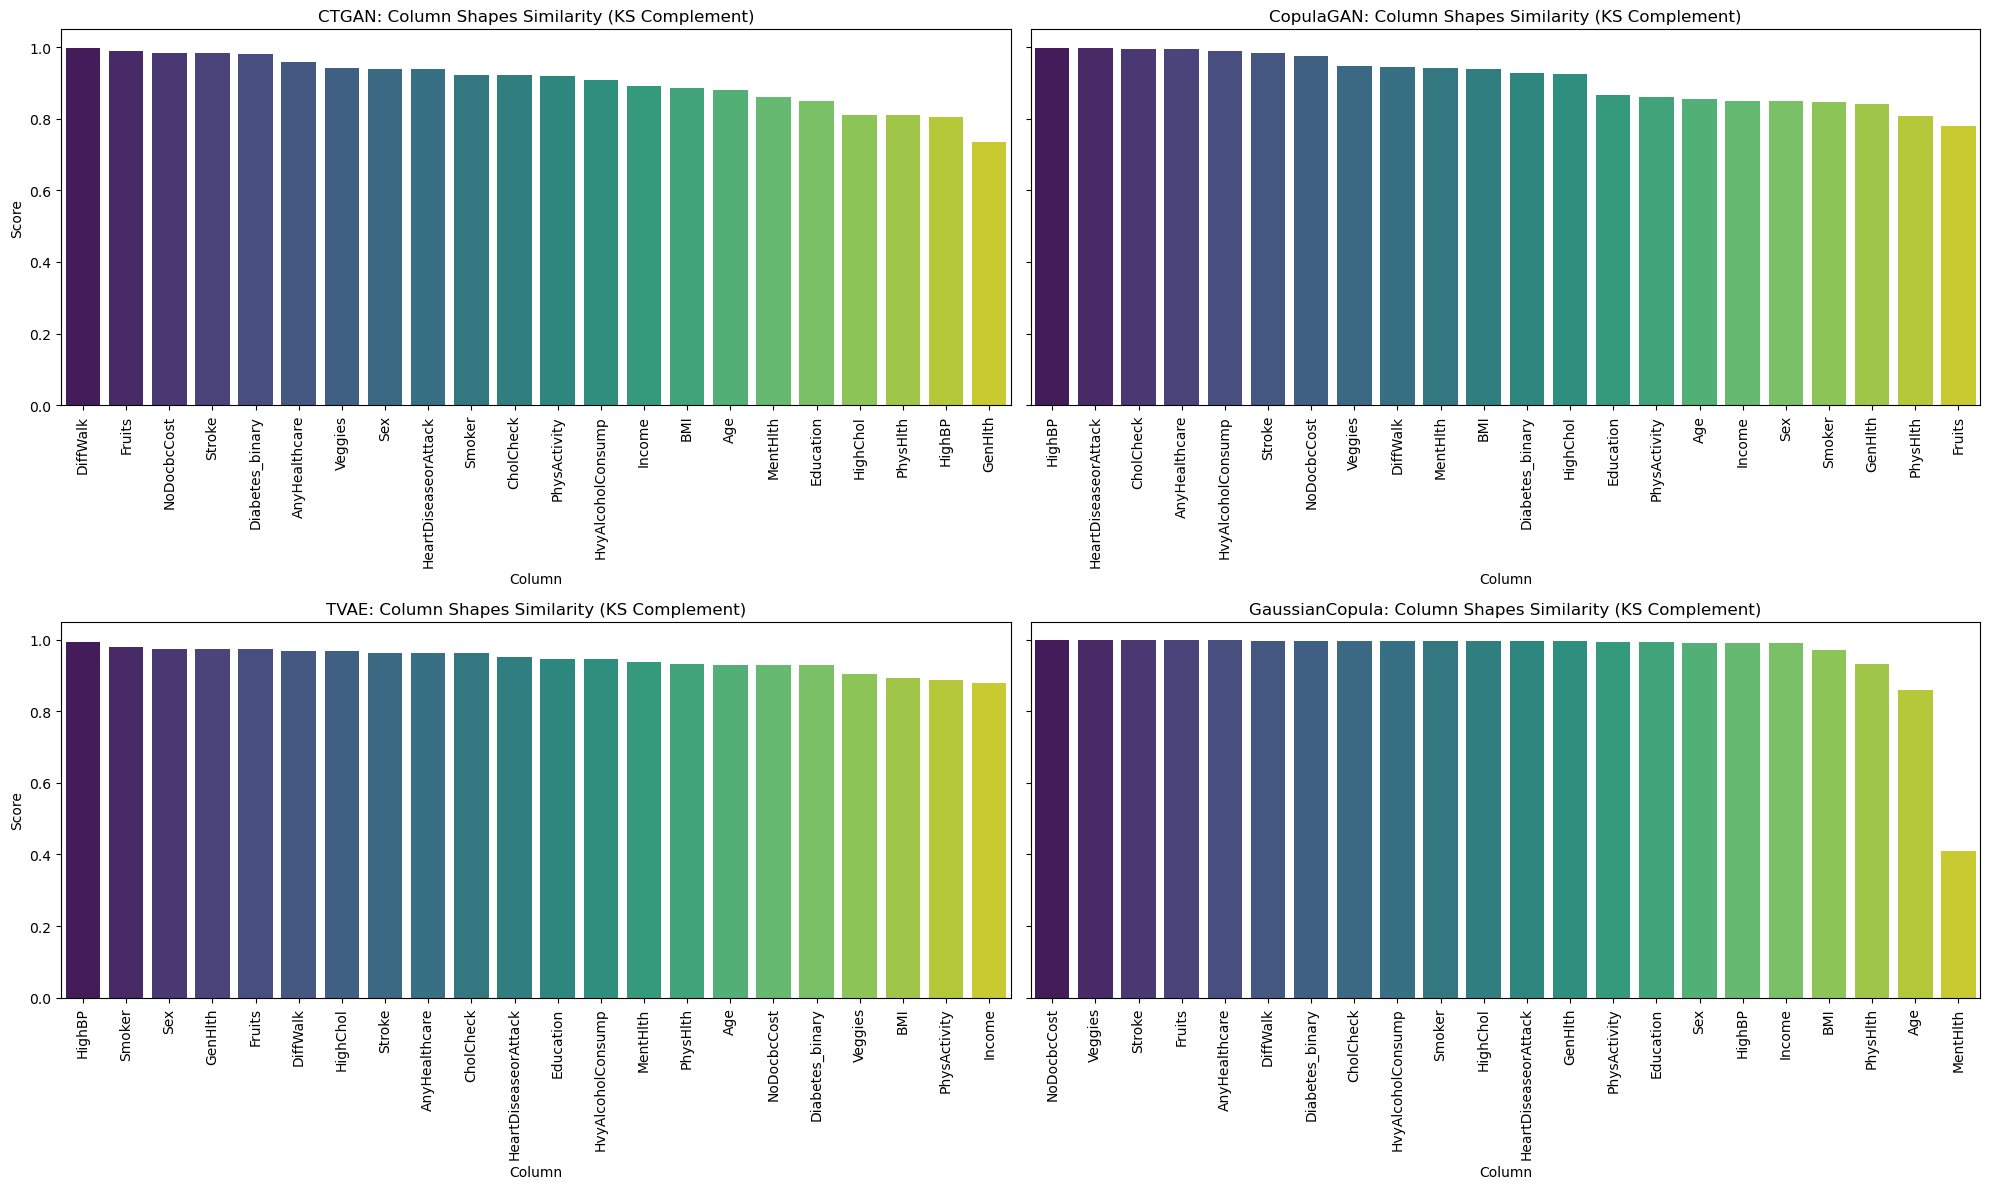

,Column,Metric,Score,Model
0,DiffWalk,TVComplement,0.9984,CTGAN
1,Fruits,TVComplement,0.9890,CTGAN
2,NoDocbcCost,TVComplement,0.9850,CTGAN
3,Stroke,TVComplement,0.9838,CTGAN
4,Diabetes_binary,TVComplement,0.9809,CTGAN
5,AnyHealthcare,TVComplement,0.9590,CTGAN
6,Veggies,TVComplement,0.9415,CTGAN
7,Sex,TVComplement,0.9389,CTGAN
8,HeartDiseaseorAttack,TVComplement,0.9387,CTGAN
9,Smoker,TVComplement,0.9220,CTGAN


In [12]:
import warnings
warnings.filterwarnings("ignore")

from sdv.evaluation.single_table import QualityReport
from sdv.metadata import SingleTableMetadata
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "diagnosis"

real_eval = data.drop(columns=[target_col], errors="ignore").copy()

metadata_eval = SingleTableMetadata()
metadata_eval.detect_from_dataframe(real_eval)

column_shape_details = {}

for model_name in model_order:
    synth_eval = synthetic_datasets[model_name].drop(columns=[target_col], errors="ignore").copy()
    synth_eval = synth_eval[real_eval.columns]

    qr = QualityReport()
    qr.generate(
        real_data=real_eval,
        synthetic_data=synth_eval,
        metadata=metadata_eval.to_dict()
    )
    details = qr.get_details("Column Shapes").sort_values("Score", ascending=False)
    column_shape_details[model_name] = details

fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    sns.barplot(
        x="Column", y="Score",
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Column Shapes Similarity (KS Complement)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)
display(combined_details.head(20))

### 1.2. Jensen–Shannon divergence

In [10]:
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")


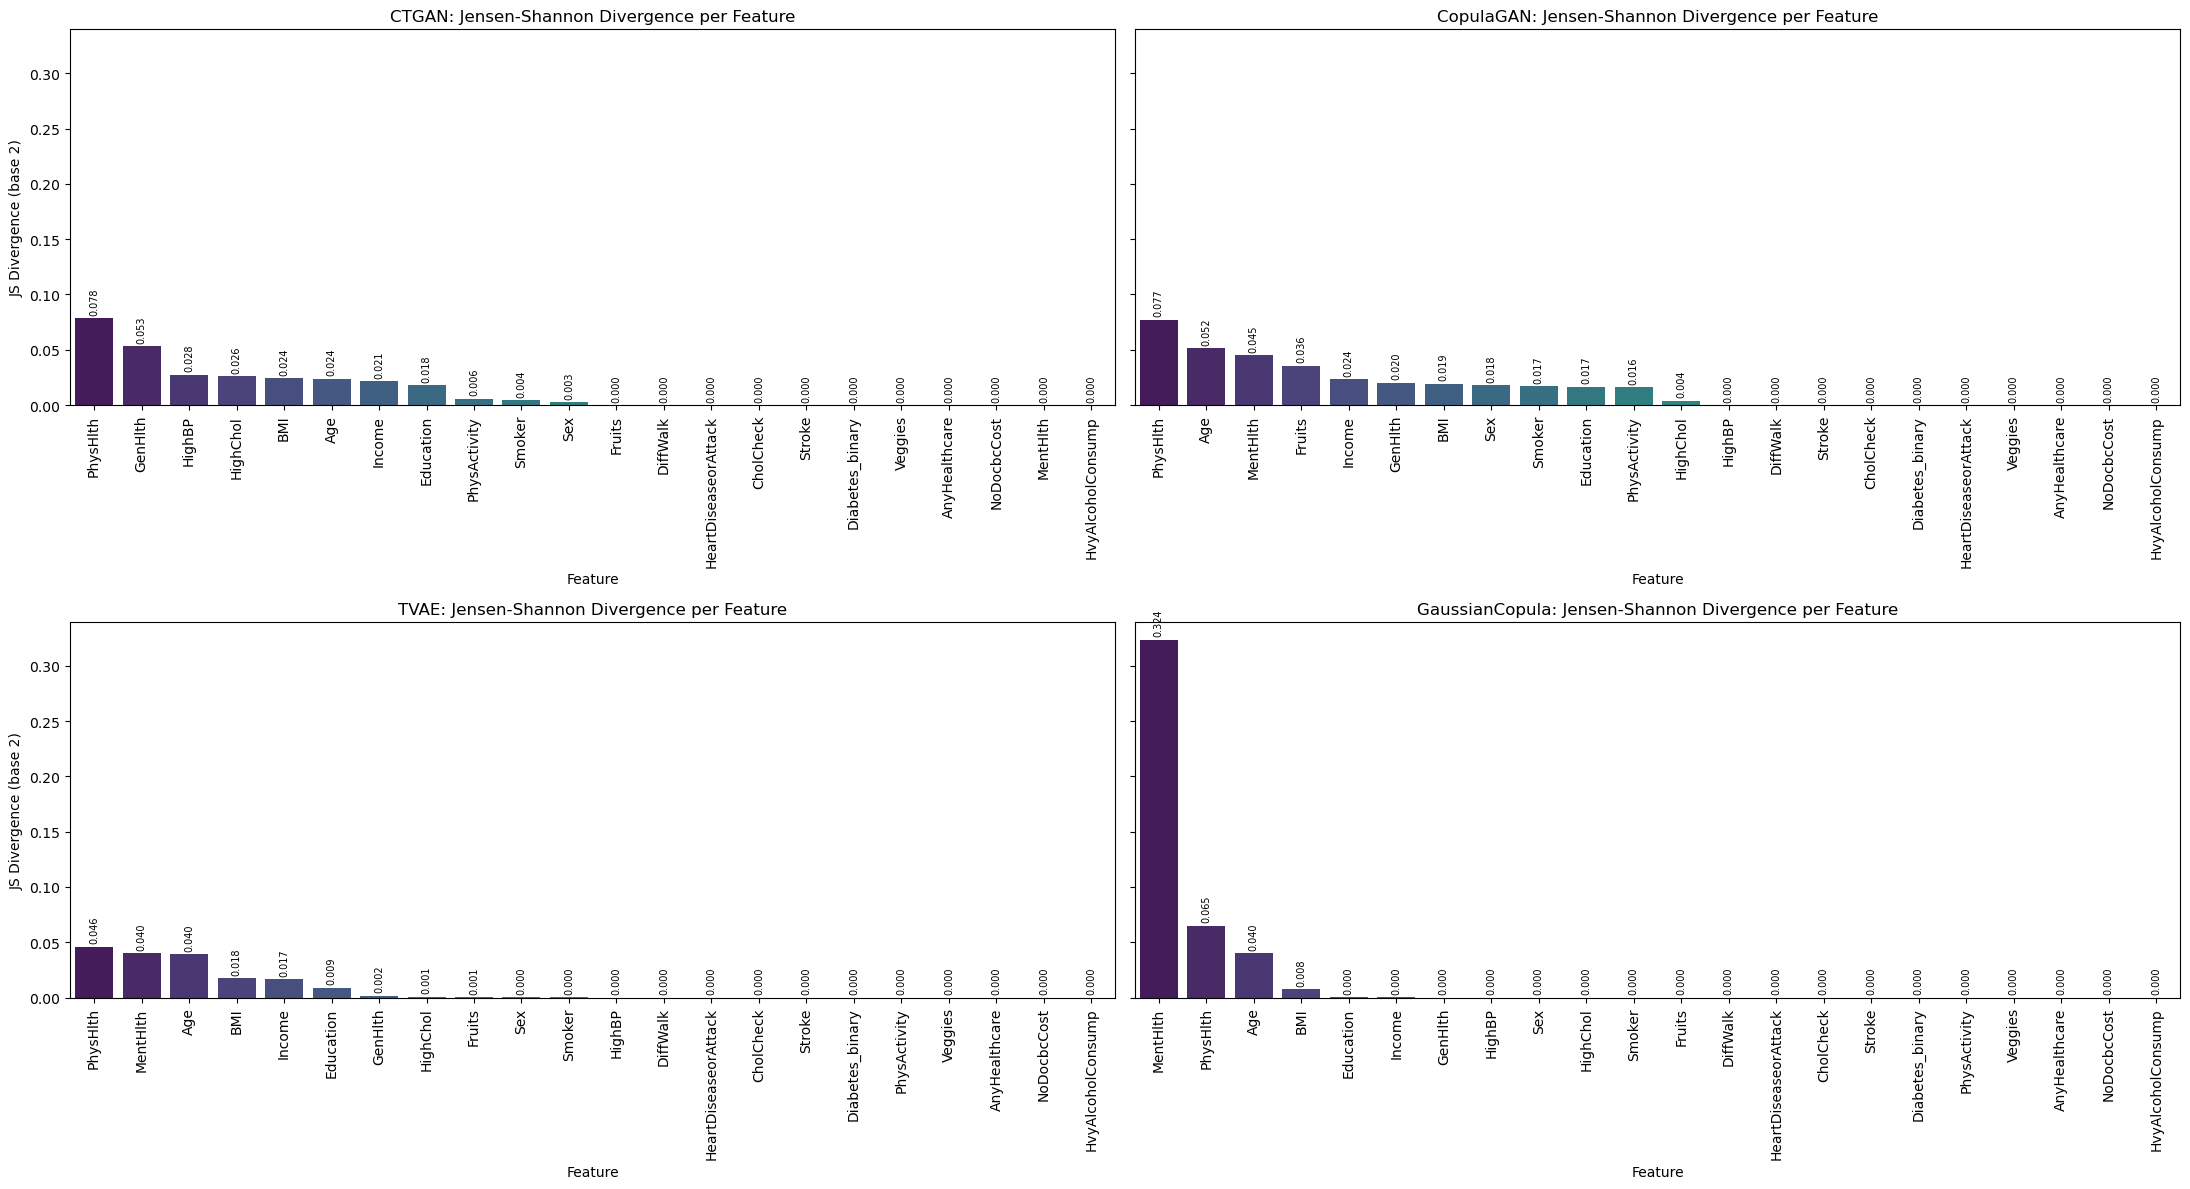

,Feature,JS_Divergence,Model
0,PhysHlth,0.078330,CTGAN
1,GenHlth,0.053374,CTGAN
2,HighBP,0.027619,CTGAN
3,HighChol,0.025960,CTGAN
4,BMI,0.024148,CTGAN
5,Age,0.023873,CTGAN
6,Income,0.021443,CTGAN
7,Education,0.018302,CTGAN
8,PhysActivity,0.005817,CTGAN
9,Smoker,0.004396,CTGAN


In [14]:
import matplotlib.pyplot as plt, numpy as np
import seaborn as sns
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
js_results_by_model = {}

# Compute JS divergence for each model
for model_name in model_order:
    js_df = compute_js_divergence(
        data,
        synthetic_datasets[model_name],
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)
    js_results_by_model[model_name] = js_df

# Plot all 4 models in one figure (2x2)
fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]
    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df,
        palette="viridis",
        ax=ax
    )

    # Add value labels
    for bar in bars.patches:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.003,
            f"{yval:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    ax.set_title(f"{model_name}: Jensen-Shannon Divergence per Feature")
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence (base 2)")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

# Optional: combined table for quick comparison
all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)
display(all_js.head(20))

### 1.3 Wasserstein Distance



CTGAN - Wasserstein Distance:
HighBP: 0.1947
HighChol: 0.1890
CholCheck: 0.0790
BMI: 0.0242
Smoker: 0.0780
Stroke: 0.0162
HeartDiseaseorAttack: 0.0613
PhysActivity: 0.0814
Fruits: 0.0110
Veggies: 0.0585
HvyAlcoholConsump: 0.0903
AnyHealthcare: 0.0410
NoDocbcCost: 0.0150
GenHlth: 0.0845
MentHlth: 0.0239
PhysHlth: 0.0968
DiffWalk: 0.0016
Sex: 0.0611
Age: 0.0422
Education: 0.0589
Income: 0.0386
Diabetes_binary: 0.0191

CopulaGAN - Wasserstein Distance:
HighBP: 0.0013
HighChol: 0.0749
CholCheck: 0.0041
BMI: 0.0134
Smoker: 0.1533
Stroke: 0.0156
HeartDiseaseorAttack: 0.0016
PhysActivity: 0.1383
Fruits: 0.2208
Veggies: 0.0528
HvyAlcoholConsump: 0.0110
AnyHealthcare: 0.0045
NoDocbcCost: 0.0246
GenHlth: 0.0644
MentHlth: 0.0406
PhysHlth: 0.1311
DiffWalk: 0.0548
Sex: 0.1514
Age: 0.0723
Education: 0.0373
Income: 0.0392
Diabetes_binary: 0.0733

TVAE - Wasserstein Distance:
HighBP: 0.0062
HighChol: 0.0322
CholCheck: 0.0378
BMI: 0.0127
Smoker: 0.0218
Stroke: 0.0364
HeartDiseaseorAttack: 0.0473
PhysA

,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein
0,GaussianCopula,0.024006,0.003563,0.398213
1,TVAE,0.039536,0.031600,0.112100
2,CTGAN,0.062105,0.058680,0.194700
3,CopulaGAN,0.062756,0.046697,0.220800


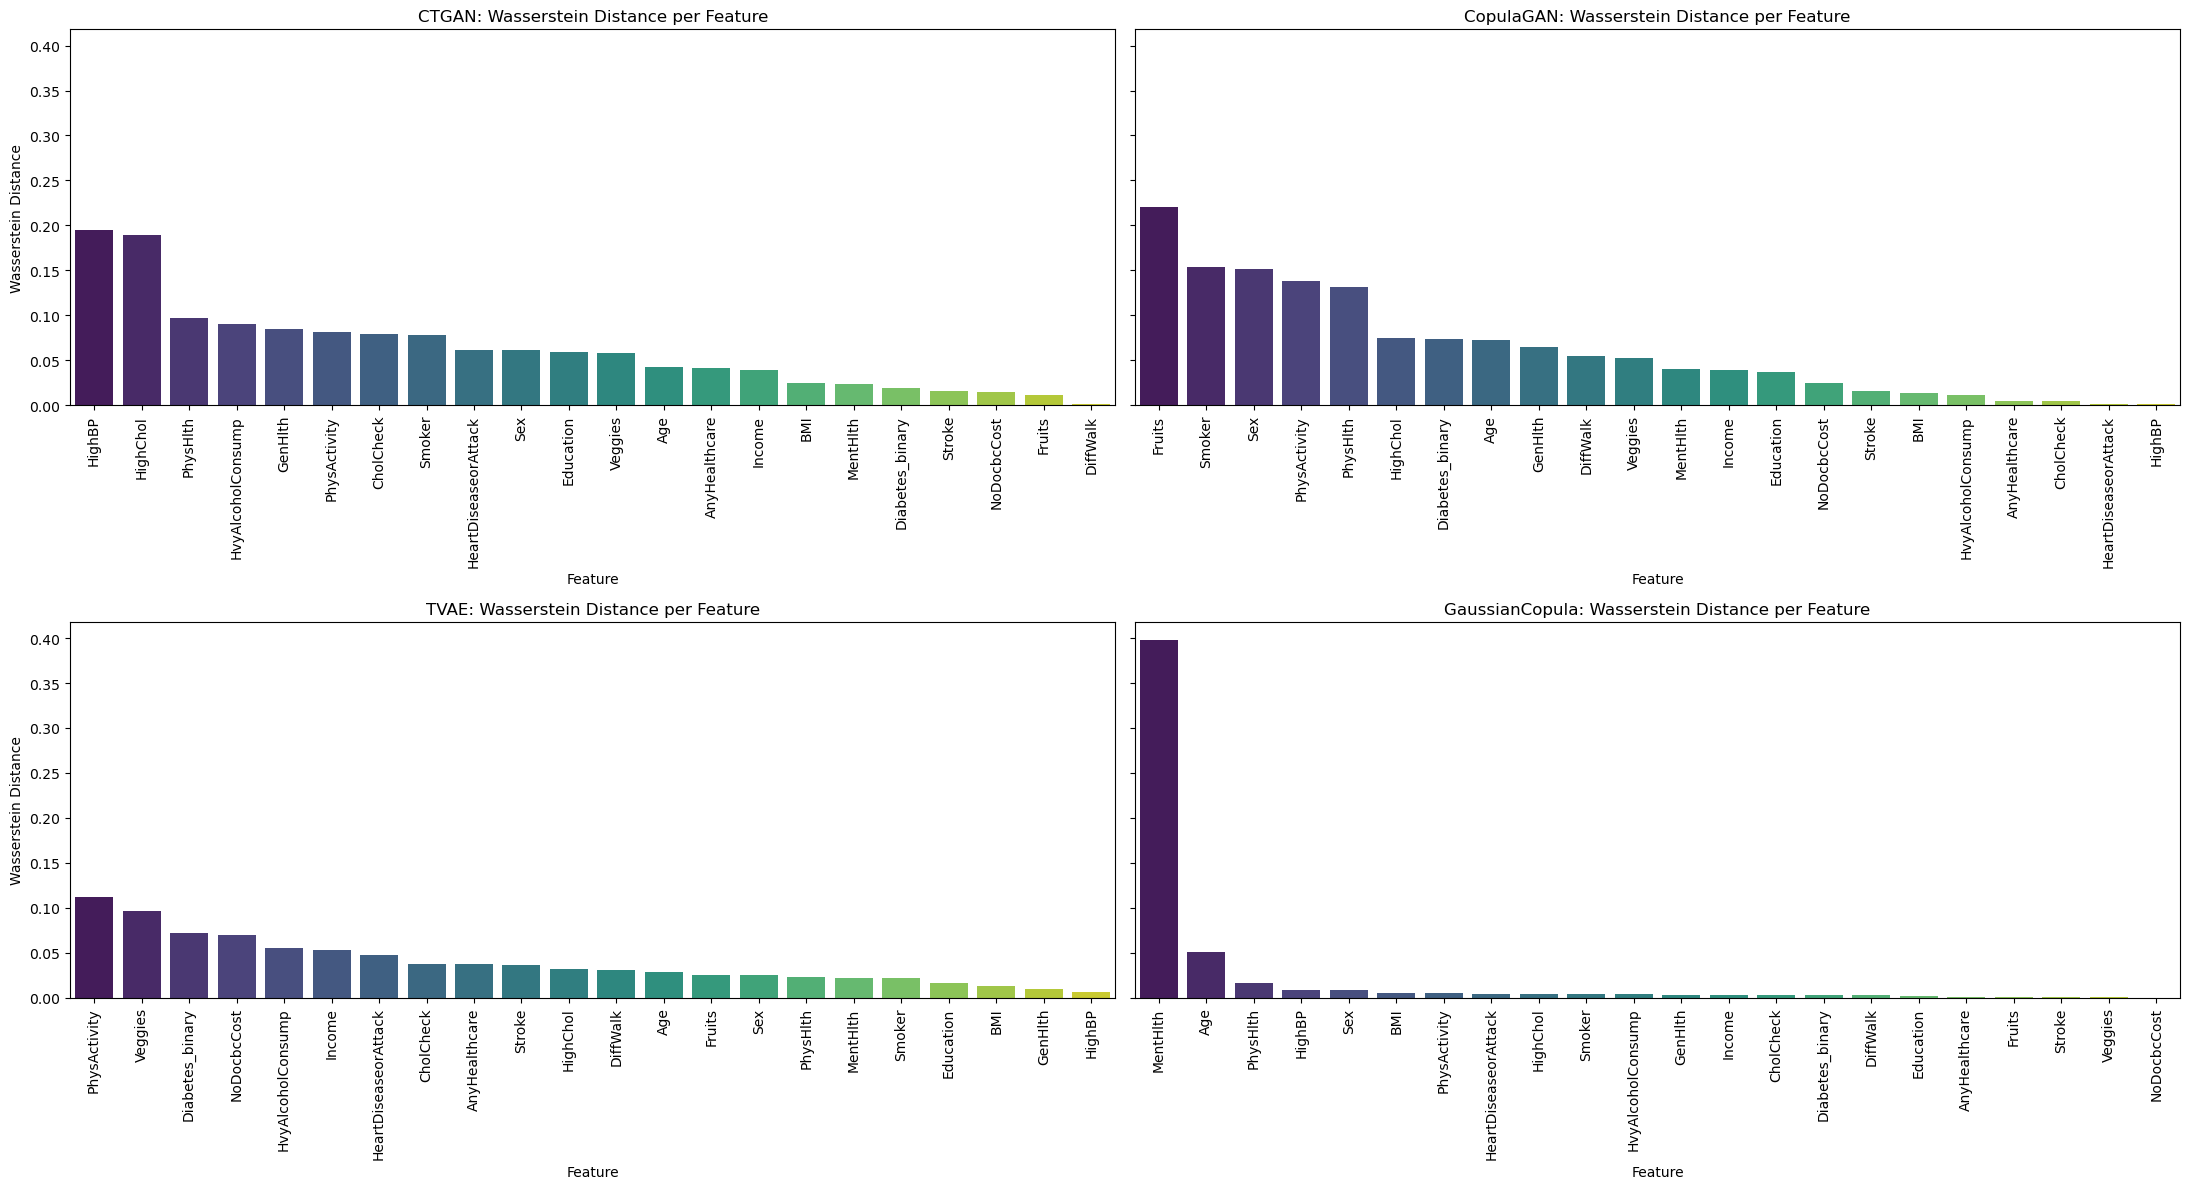

In [15]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assumes these already exist:
# - data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Scale real data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(data),
    columns=data.columns
)

wasserstein_by_model = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]

    # Ensure same column order as real data
    synth_df = synth_df[data.columns]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=synth_df.columns
    )

    dists = []
    print(f"\n{model_name} - Wasserstein Distance:")
    for col in data.columns:
        dist = wasserstein_distance(real_scaled[col], synthetic_scaled[col])
        dists.append((col, dist))
        print(f"{col}: {dist:.4f}")

    dist_df = pd.DataFrame(dists, columns=["Feature", "Wasserstein_Distance"]).sort_values(
        "Wasserstein_Distance", ascending=False
    )
    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": dist_df["Wasserstein_Distance"].mean(),
        "Median_Wasserstein": dist_df["Wasserstein_Distance"].median(),
        "Max_Wasserstein": dist_df["Wasserstein_Distance"].max(),
    })

# Summary table (lower is better)
summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

# Plot all 4 models in one figure
fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name]
    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Wasserstein Distance per Feature")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.tight_layout()
plt.show()

### 1.4 Gower Distance

In [19]:
import numpy as np
import pandas as pd
import gower

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "Diabetes_binary"
id_col = "ID"
drop_cols = [c for c in [id_col, target_col] if c in data.columns]

X_real = data.drop(columns=drop_cols, errors="ignore").copy()

gower_results = []

for model_name in model_order:
    X_synth = synthetic_datasets[model_name].drop(columns=drop_cols, errors="ignore").copy()

    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = X_real[common_cols].reset_index(drop=True).copy()
    Xs = X_synth[common_cols].reset_index(drop=True).copy()

    num_cols = Xr.select_dtypes(include=[np.number]).columns
    Xr[num_cols] = Xr[num_cols].astype(np.float64)
    Xs[num_cols] = Xs[num_cols].astype(np.float64)

    gower_real = 1.0 - gower.gower_matrix(Xr)
    gower_synth = 1.0 - gower.gower_matrix(Xs)

    real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
    synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

    max_intra_real = float(np.max(real_upper))
    avg_intra_real = float(np.mean(real_upper))
    max_intra_synth = float(np.max(synth_upper))
    avg_intra_synth = float(np.mean(synth_upper))

    combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
    gower_combined = 1.0 - gower.gower_matrix(combined)
    n_real = len(Xr)
    cross_block = gower_combined[:n_real, n_real:]

    max_cross = float(np.max(cross_block))
    avg_cross = float(np.mean(cross_block))

    print(f"\n{model_name} - Gower Similarity:")
    print("Intra-set Similarity (Real):")
    print(f"Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}\n")
    print("Intra-set Similarity (Synthetic):")
    print(f"Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}\n")
    print("Cross-set Similarity (Real vs Synthetic):")
    print(f"Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

    gower_results.append({
        "Model": model_name,
        "Max_Intra_Real": max_intra_real,
        "Avg_Intra_Real": avg_intra_real,
        "Max_Intra_Synth": max_intra_synth,
        "Avg_Intra_Synth": avg_intra_synth,
        "Max_Cross_Real_vs_Synth": max_cross,
        "Avg_Cross_Real_vs_Synth": avg_cross,
    })

gower_summary_df = pd.DataFrame(gower_results)
display(gower_summary_df)


CTGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.7306

Intra-set Similarity (Synthetic):
Max = 1.0000, Avg = 0.7069

Cross-set Similarity (Real vs Synthetic):
Max = 1.0000, Avg = 0.7122

CopulaGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.7306

Intra-set Similarity (Synthetic):
Max = 1.0000, Avg = 0.7106

Cross-set Similarity (Real vs Synthetic):
Max = 1.0000, Avg = 0.7143

TVAE - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.7306

Intra-set Similarity (Synthetic):
Max = 1.0000, Avg = 0.7749

Cross-set Similarity (Real vs Synthetic):
Max = 1.0000, Avg = 0.7524

GaussianCopula - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.7306

Intra-set Similarity (Synthetic):
Max = 1.0000, Avg = 0.7151

Cross-set Similarity (Real vs Synthetic):
Max = 1.0000, Avg = 0.7160


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,CTGAN,1.0,0.730593,1.0,0.706852,1.0,0.712221
1,CopulaGAN,1.0,0.730593,1.0,0.710597,1.0,0.714305
2,TVAE,1.0,0.730593,1.0,0.774874,1.0,0.752427
3,GaussianCopula,1.0,0.730593,1.0,0.715059,1.0,0.716012


### 1.5 t-SNE Visualization


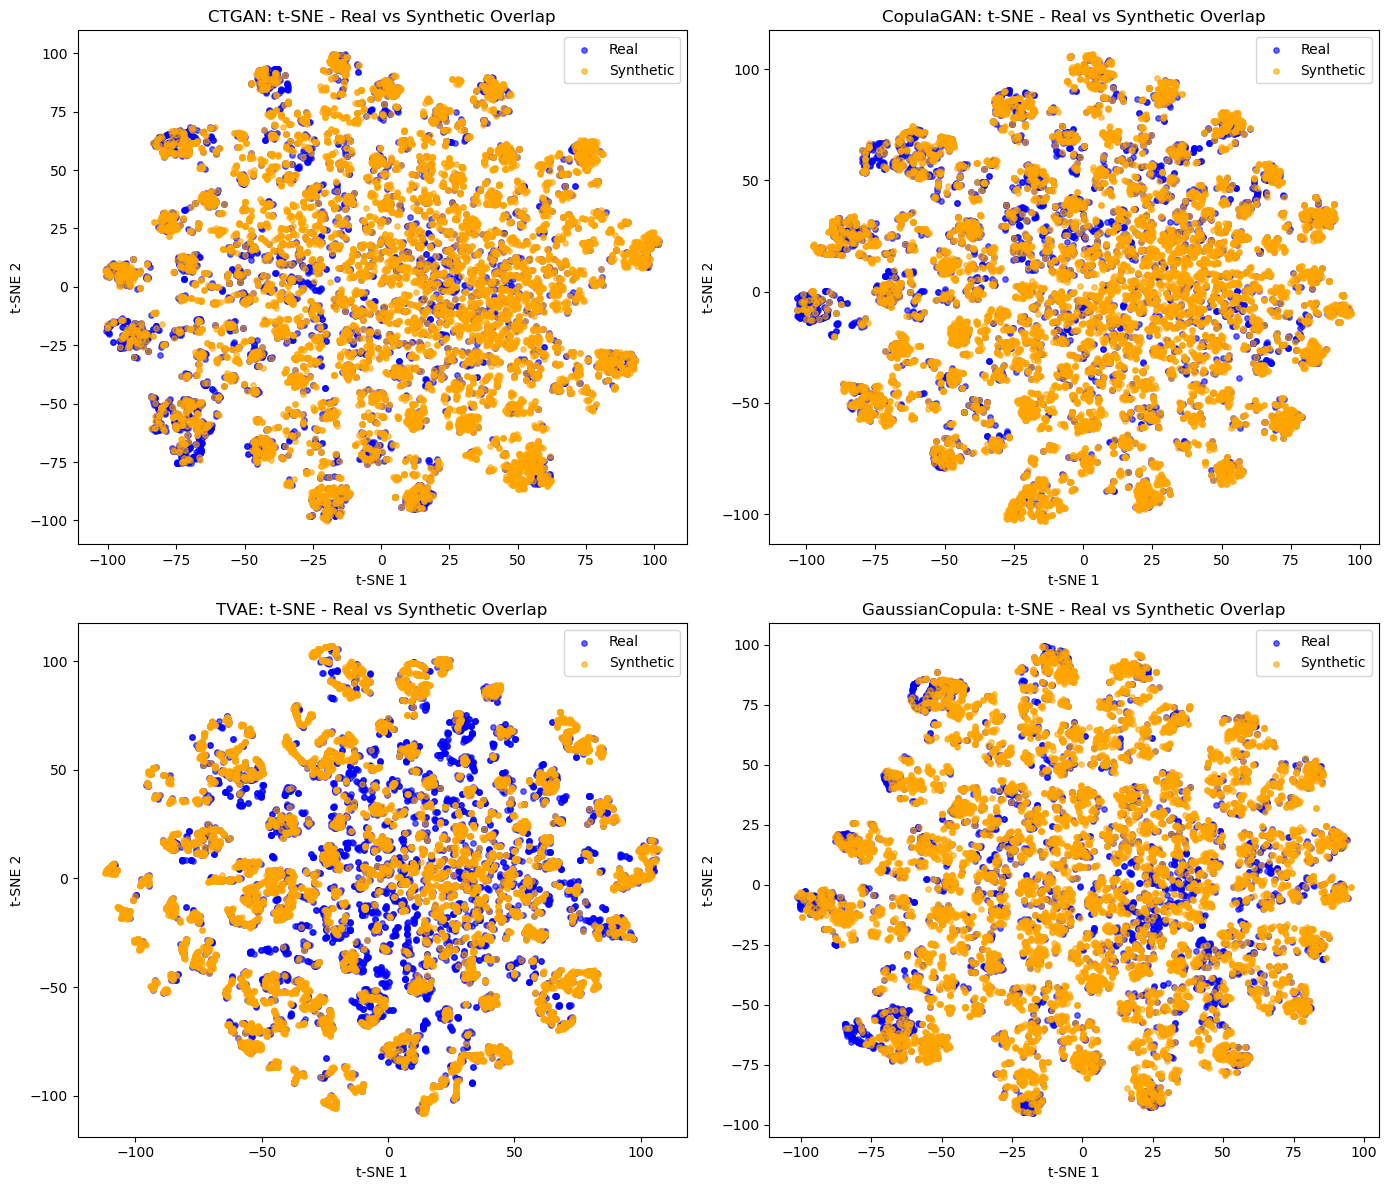

In [20]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumes:
# - data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Scale real data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(data),
    columns=data.columns
)

# Create 2x2 t-SNE plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_datasets[model_name][data.columns]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=synth_df.columns
    )

    combined = np.vstack([real_scaled.values, synthetic_scaled.values])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))

    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=15, label="Real"
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=15, label="Synthetic"
    )

    ax.set_title(f"{model_name}: t-SNE - Real vs Synthetic Overlap")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()

### 1.6 MMD (Maximum Mean Discrepancy)


In [23]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel

def _sample_rows(X, max_rows=2000, seed=42):
    if X.shape[0] <= max_rows:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=max_rows, replace=False)
    return X[idx]

def _median_gamma(X, Y):
    Z = np.vstack([X, Y])
    n = Z.shape[0]
    take = min(1200, n)
    idx = np.random.default_rng(42).choice(n, size=take, replace=False)
    Zs = Z[idx]
    d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
    vals = d2[np.triu_indices_from(d2, k=1)]
    med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
    return 1.0 / (2.0 * med)

def compute_mmd_rbf_safe(X, Y, gamma=None):
    if gamma is None:
        gamma = _median_gamma(X, Y)
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    return float(Kxx.mean() + Kyy.mean() - 2.0 * Kxy.mean())

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "Diabetes_binary"
id_col = "ID"
drop_cols = [c for c in [id_col, target_col] if c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
mmd_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].to_numpy(dtype=np.float64)
    X_synth = synth_features[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    Xr = _sample_rows(X_real_scaled, max_rows=2000, seed=42)
    Xs = _sample_rows(X_synth_scaled, max_rows=2000, seed=42)

    mmd_score = compute_mmd_rbf_safe(Xr, Xs, gamma=None)
    mmd_results.append({"Model": model_name, "MMD_Score": mmd_score})

    print(f"{model_name} - MMD score: {mmd_score:.6f}")

mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print("\nMMD comparison (lower is better):")
display(mmd_summary_df)

CTGAN - MMD score: 0.019512
CopulaGAN - MMD score: 0.014304
TVAE - MMD score: 0.014660
GaussianCopula - MMD score: 0.039741

MMD comparison (lower is better):


,Model,MMD_Score
0,CopulaGAN,0.014304
1,TVAE,0.014660
2,CTGAN,0.019512
3,GaussianCopula,0.039741


### 1.7 Cosine Similarity


In [22]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "Diabetes_binary"
id_col = "ID"
drop_cols = [c for c in [id_col, target_col] if c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
similarity_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].astype(np.float64)
    X_synth = synth_features[common_cols].astype(np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = float(np.mean(cross_sim))
    max_sim = float(np.max(cross_sim))

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)


CTGAN - Sample-Level Similarity:
Average cosine similarity: -0.0049
Maximum cosine similarity: 1.0000

CopulaGAN - Sample-Level Similarity:
Average cosine similarity: -0.0003
Maximum cosine similarity: 1.0000

TVAE - Sample-Level Similarity:
Average cosine similarity: 0.0251
Maximum cosine similarity: 1.0000

GaussianCopula - Sample-Level Similarity:
Average cosine similarity: -0.0042
Maximum cosine similarity: 1.0000

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,TVAE,0.025070,1.0
1,CopulaGAN,-0.000336,1.0
2,GaussianCopula,-0.004156,1.0
3,CTGAN,-0.004886,1.0


### 1.8 Nearest Neighbours 


In [24]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "Diabetes_binary"
id_col = "ID"
drop_cols = [c for c in [id_col, target_col] if c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].astype(np.float64)
    X_synth = synth_features[common_cols].astype(np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)

    avg_nn_dist = float(np.mean(distances))
    min_nn_dist = float(np.min(distances))
    p5_nn_dist = float(np.percentile(distances, 5))

    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)


CTGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 2.2944
Minimum NN Distance (Synthetic -> Real): 0.0000
5th Percentile NN Distance: 0.6082

CopulaGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 2.1580
Minimum NN Distance (Synthetic -> Real): 0.0000
5th Percentile NN Distance: 0.4875

TVAE - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.0305
Minimum NN Distance (Synthetic -> Real): 0.0000
5th Percentile NN Distance: 0.1375

GaussianCopula - Privacy Check:
Average NN Distance (Synthetic -> Real): 2.6234
Minimum NN Distance (Synthetic -> Real): 0.0000
5th Percentile NN Distance: 0.9527

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,GaussianCopula,2.623425,0.0,0.952743
1,CTGAN,2.294401,0.0,0.608160
2,CopulaGAN,2.158009,0.0,0.487498
3,TVAE,1.030506,0.0,0.137542


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,26.911364,10.844658,14.129601
1,CopulaGAN,20.300259,17.665094,10.617060
2,TVAE,20.710261,5.580357,24.812616
3,GaussianCopula,20.260145,0.893256,4.371937


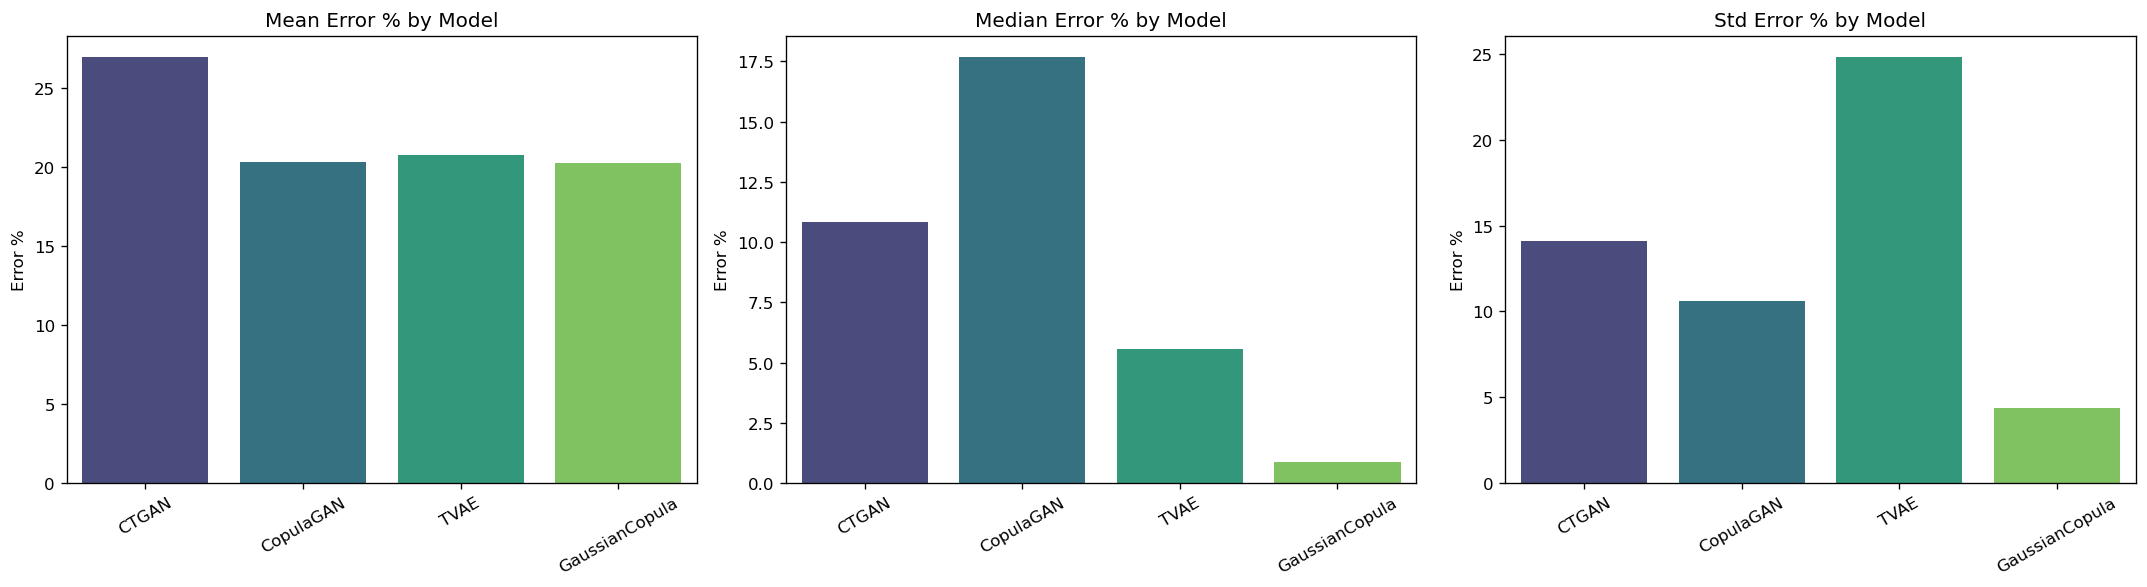

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

drop_from_metrics = []
if "ID" in num_cols:
    drop_from_metrics.append("ID")
if "Diabetes_binary" in num_cols:
    drop_from_metrics.append("Diabetes_binary")

num_cols = [c for c in num_cols if c not in drop_from_metrics]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_df = synth_df[real_df.columns]

    real_means = real_df[num_cols].astype(np.float64).mean()
    synth_means = synth_df[num_cols].astype(np.float64).mean()

    real_stds = real_df[num_cols].astype(np.float64).std(ddof=1)
    synth_stds = synth_df[num_cols].astype(np.float64).std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100.0
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100.0

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True))
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()

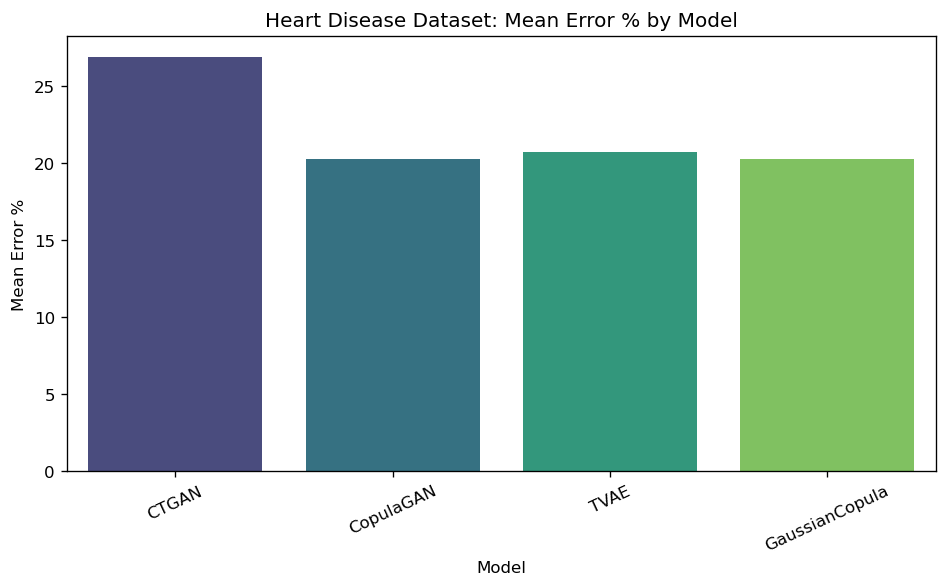

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = summary_df[["Model", "Mean Error %"]].copy()

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=plot_df, x="Model", y="Mean Error %", palette="viridis")
plt.title("Heart Disease Dataset: Mean Error % by Model")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

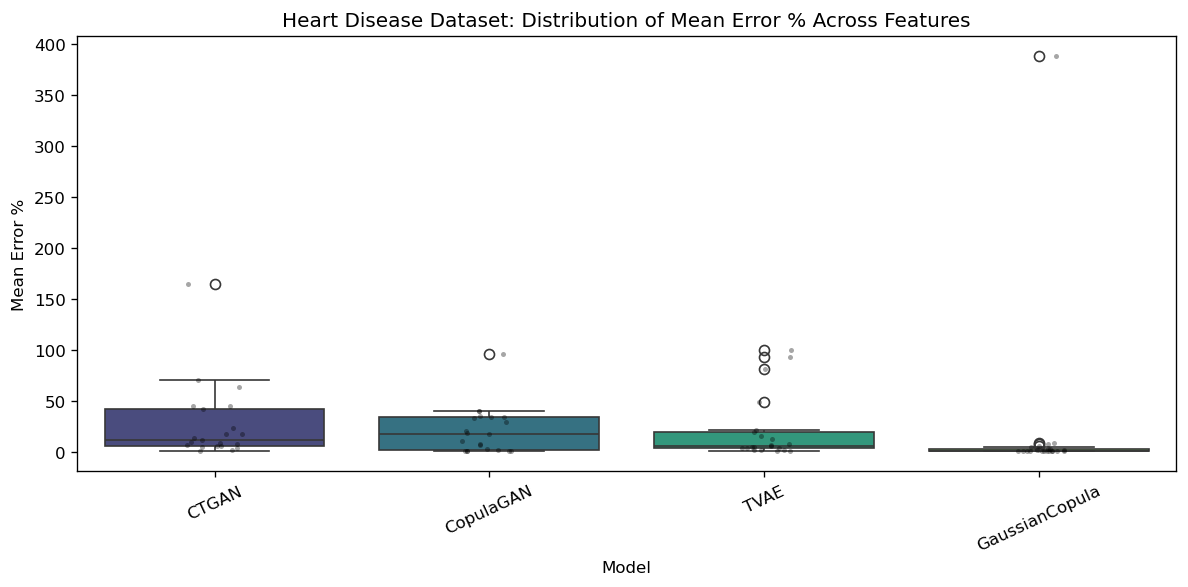

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Heart Disease Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

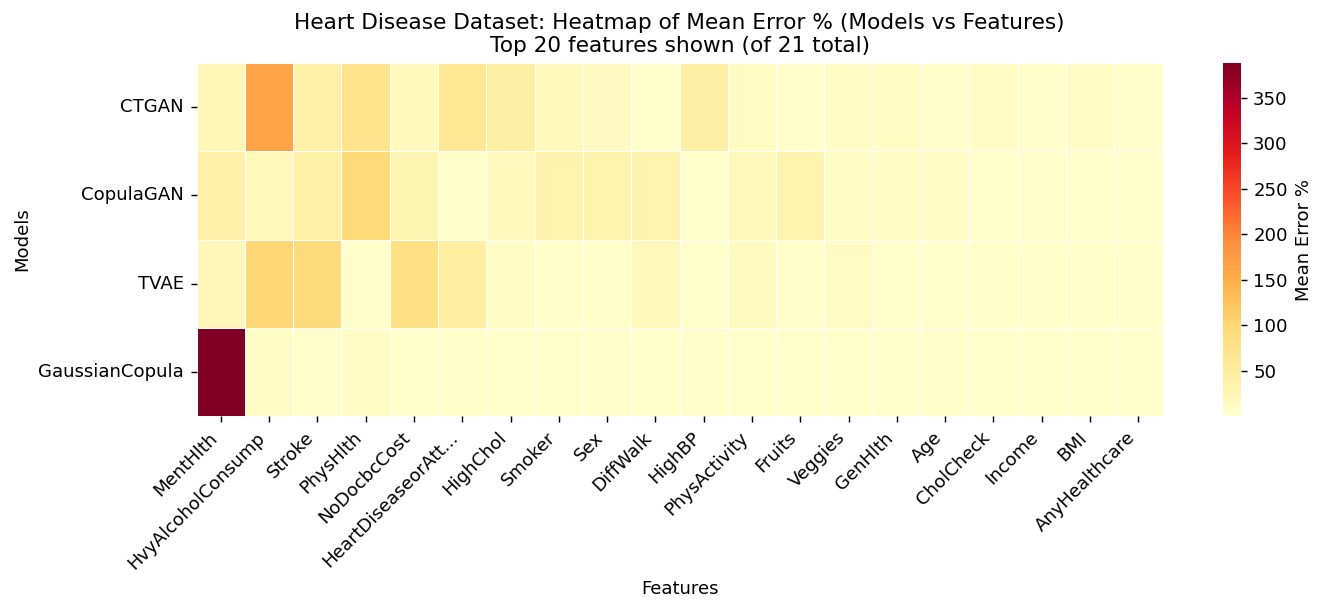

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Heart Disease Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2 Bivariate Analysis


In [40]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def bivariate_quality_heart(real_df, synth_df, target="Diabetes_binary", id_col="ID"):
    num_cols = real_df.select_dtypes(include=["number"]).columns.tolist()
    num_cols = [c for c in num_cols if c not in [target, id_col]]

    scaler = MinMaxScaler()

    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()

    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])

    results_corr = []
    results_target = []

    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            "var_a": a,
            "var_b": b,
            "delta_corr": abs(r_corr - s_corr)
        })

    if target in real_scaled.columns and target in synth_scaled.columns:
        for col in num_cols:
            r_groups = [g[col].values for _, g in real_scaled.groupby(target)]
            s_groups = [g[col].values for _, g in synth_scaled.groupby(target)]

            if len(r_groups) == 2 and len(s_groups) == 2:
                d_real = stats.wasserstein_distance(*r_groups)
                d_synth = stats.wasserstein_distance(*s_groups)
                results_target.append({
                    "feature": col,
                    "delta_wasserstein": abs(d_real - d_synth)
                })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = pd.DataFrame(results_target).sort_values("delta_wasserstein", ascending=False) if results_target else pd.DataFrame(columns=["feature", "delta_wasserstein"])

    return corr_df, target_df

In [41]:
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = data.copy()

target_col = "Diabetes_binary"
id_col = "ID"

if "bivariate_quality_heart" in globals():
    quality_fn = bivariate_quality_heart
elif "bivariate_quality_cancer" in globals():
    quality_fn = bivariate_quality_cancer
else:
    raise NameError("Define `bivariate_quality_heart` (or existing `bivariate_quality_cancer`) before running this cell.")

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_df = synth_df[real_df.columns]

    real_eval = real_df.drop(columns=[id_col], errors="ignore")
    synth_eval = synth_df.drop(columns=[id_col], errors="ignore")

    corr_results, target_results = quality_fn(
        real_df=real_eval,
        synth_df=synth_eval
    )

    all_corr_results[model_name] = corr_results
    all_target_results[model_name] = target_results

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_results.head(10))
    print("=" * 60)
    print(f"{model_name} - Features that differ most by {target_col} class:")
    display(target_results.head(10))
    print("=" * 60)

    corr_metric_col = next((c for c in ["AbsDiff", "abs_diff", "Difference", "diff"] if c in corr_results.columns), None)
    target_metric_col = next((c for c in ["AbsDiff", "abs_diff", "Difference", "diff"] if c in target_results.columns), None)

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": corr_results[corr_metric_col].iloc[0] if corr_metric_col else None,
        "MeanTop10CorrDiff": corr_results[corr_metric_col].head(10).mean() if corr_metric_col else None,
        "TopTargetDiff": target_results[target_metric_col].iloc[0] if target_metric_col else None,
        "MeanTop10TargetDiff": target_results[target_metric_col].head(10).mean() if target_metric_col else None,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


CTGAN - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
192,MentHlth,Age,0.264839
114,HeartDiseaseorAttack,DiffWalk,0.256527
113,HeartDiseaseorAttack,PhysHlth,0.252601
197,PhysHlth,Age,0.217412
71,BMI,Age,0.211641
118,HeartDiseaseorAttack,Income,0.184232
179,NoDocbcCost,Age,0.184197
136,Fruits,GenHlth,0.178504
112,HeartDiseaseorAttack,MentHlth,0.168925
183,GenHlth,PhysHlth,0.167086


CTGAN - Features that differ most by Diabetes_binary class:


,feature,delta_wasserstein
16,DiffWalk,0.229534
6,HeartDiseaseorAttack,0.228985
15,PhysHlth,0.227944
20,Income,0.148610
14,MentHlth,0.102897
5,Stroke,0.080515
4,Smoker,0.067043
10,HvyAlcoholConsump,0.061088
19,Education,0.059049
1,HighChol,0.055905



CopulaGAN - Largest differences in pairwise correlations:


...


GaussianCopula - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
183,GenHlth,PhysHlth,0.462251
209,Education,Income,0.447054
184,GenHlth,DiffWalk,0.403145
188,GenHlth,Income,0.357873
195,PhysHlth,DiffWalk,0.355062
12,HighBP,GenHlth,0.310402
203,DiffWalk,Income,0.300406
111,HeartDiseaseorAttack,GenHlth,0.286685
182,GenHlth,MentHlth,0.275936
199,PhysHlth,Income,0.268207


GaussianCopula - Features that differ most by Diabetes_binary class:


,feature,delta_wasserstein
0,HighBP,0.278682
1,HighChol,0.235387
13,GenHlth,0.205680
16,DiffWalk,0.159295
20,Income,0.133579
6,HeartDiseaseorAttack,0.117432
15,PhysHlth,0.109743
7,PhysActivity,0.107720
4,Smoker,0.093628
18,Age,0.088942


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,CTGAN,None,None,None,None
1,CopulaGAN,None,None,None,None
2,TVAE,None,None,None,None
3,GaussianCopula,None,None,None,None


### 3 Multivariate Analysis


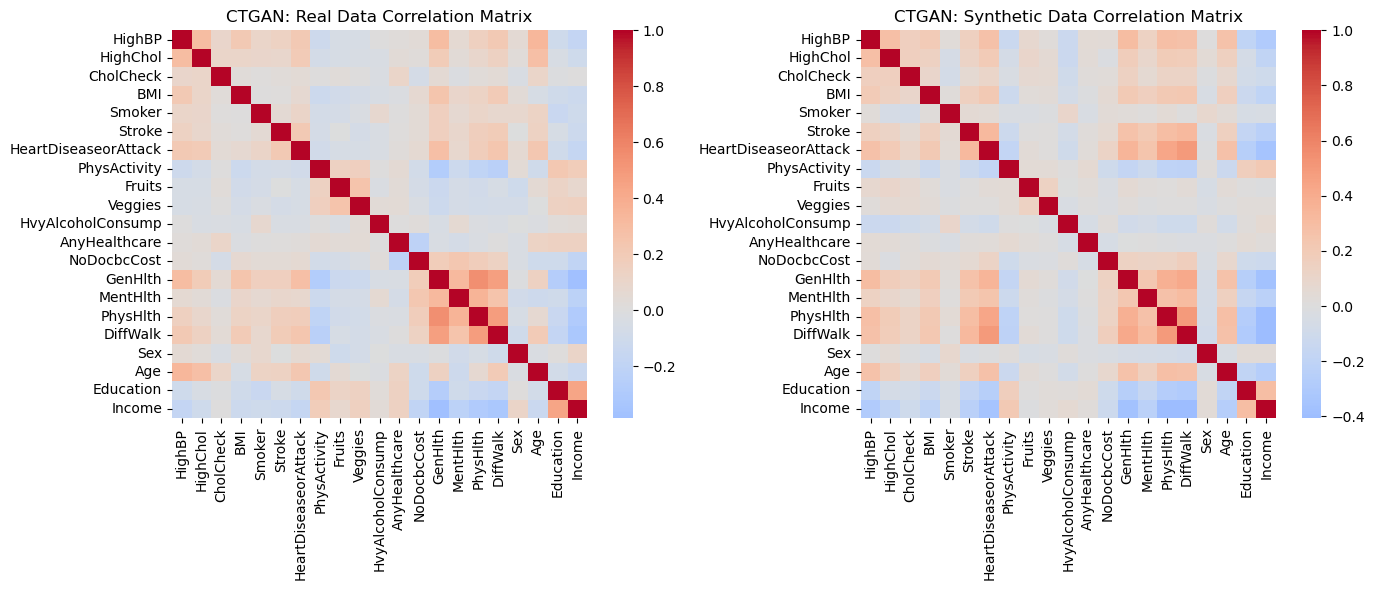

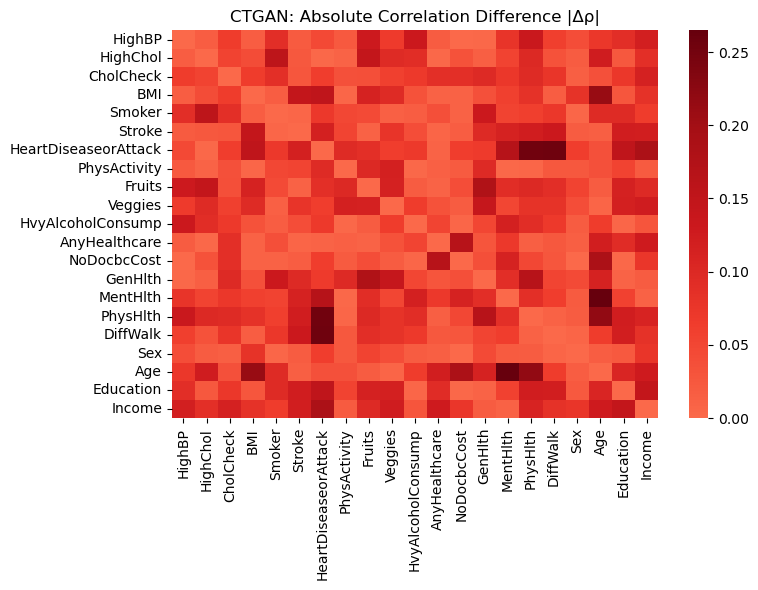

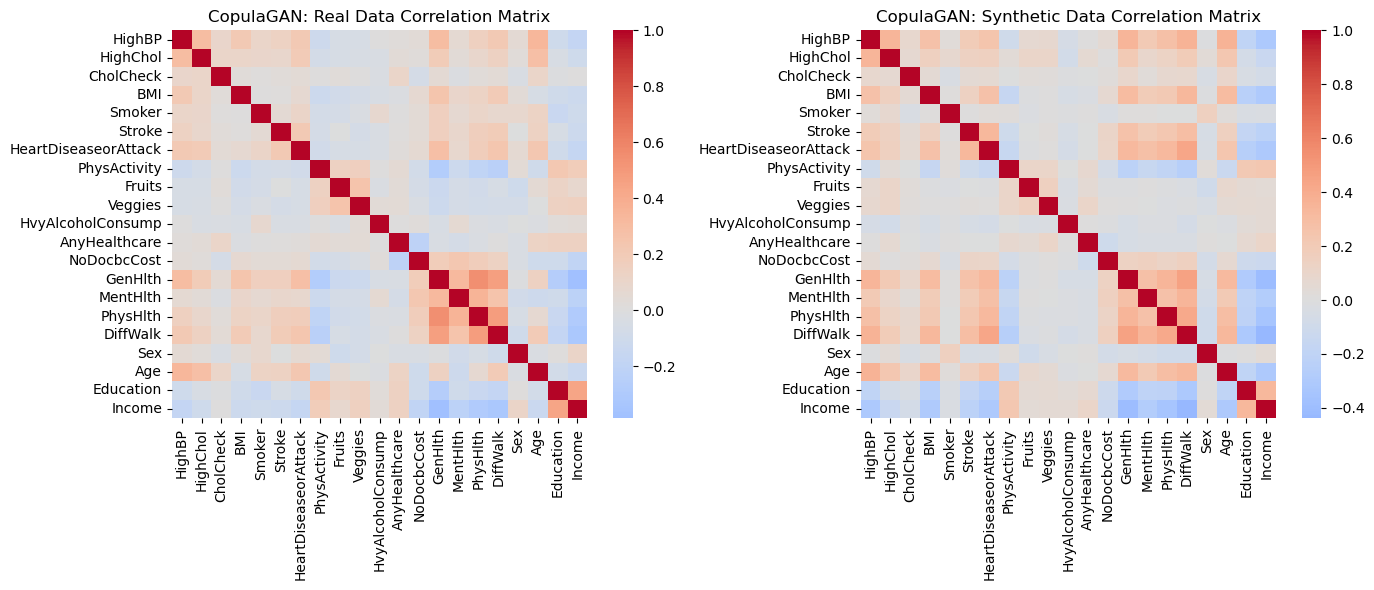

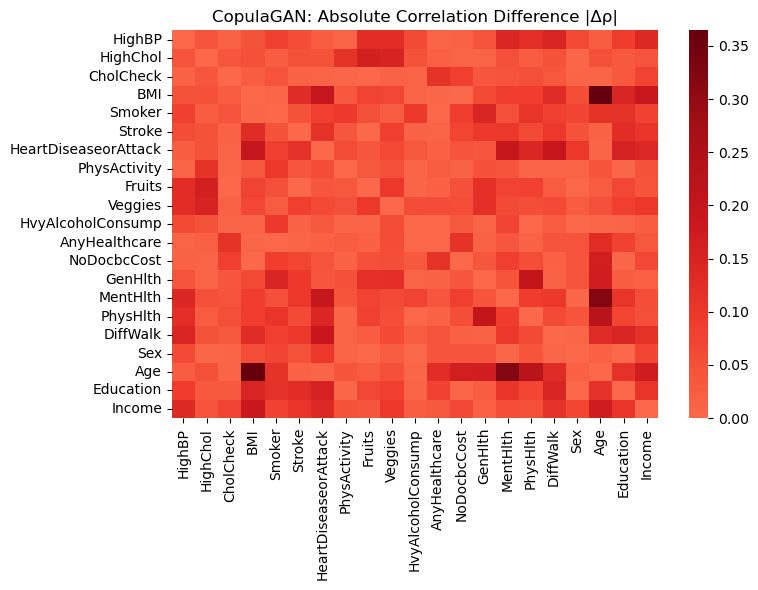

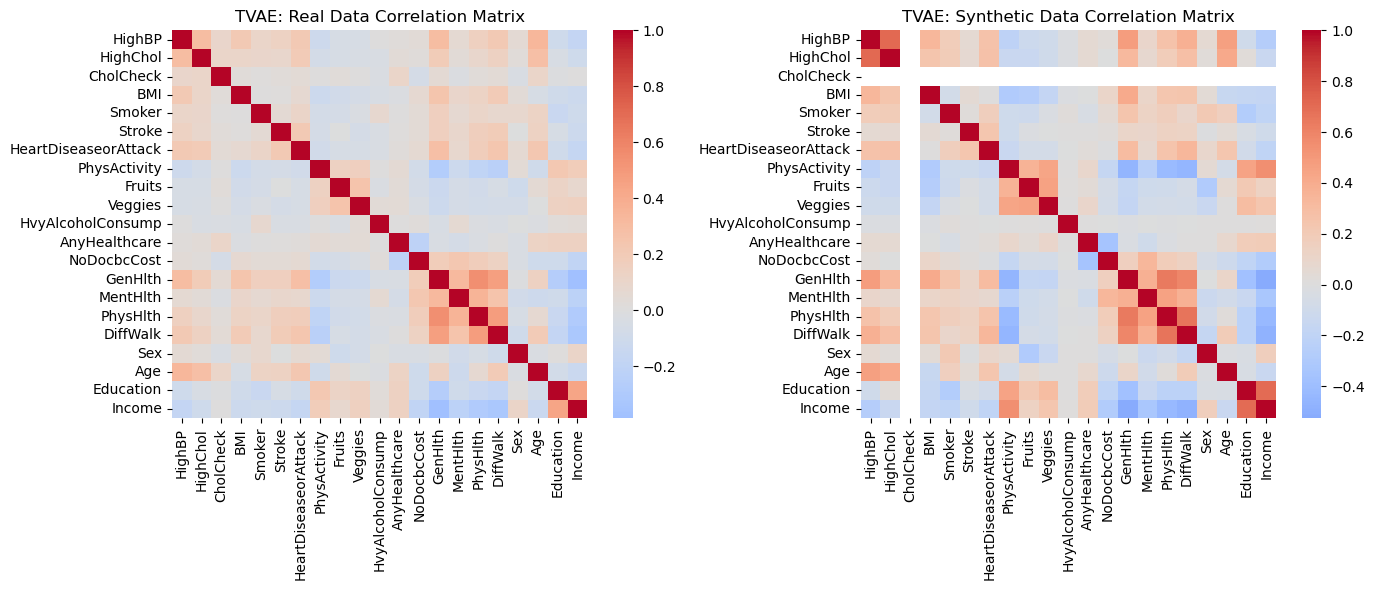

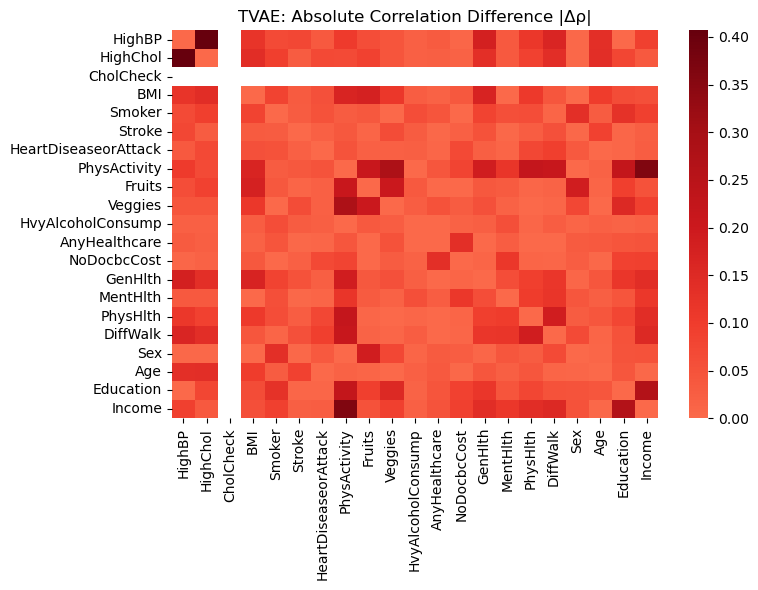

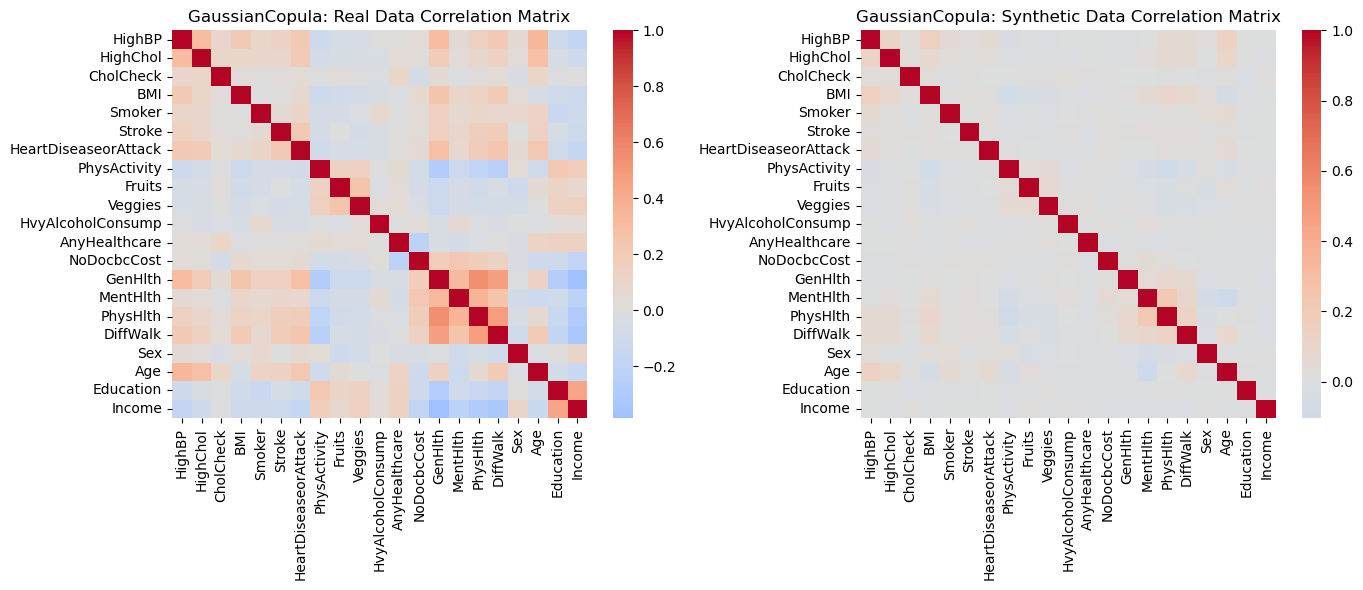

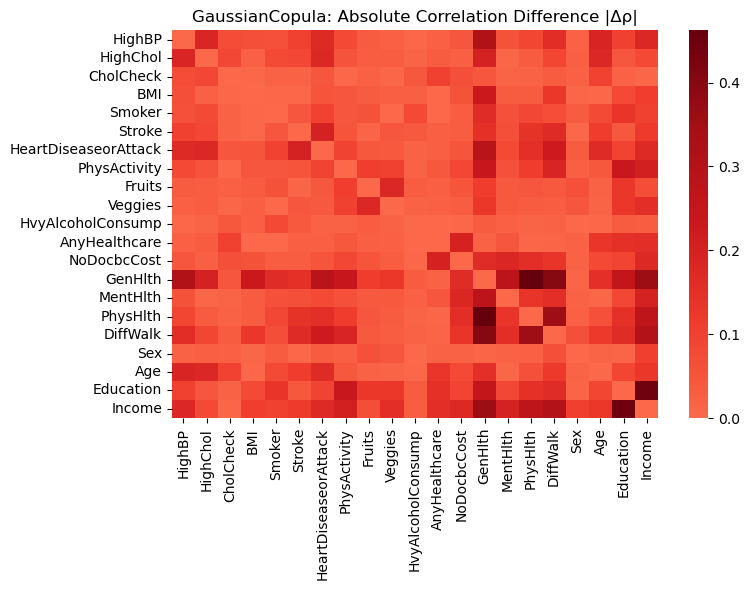

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
target_col = "Diabetes_binary"
id_col = "ID"

num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in [target_col, id_col]]

real_corr = real_df[num_cols].corr()

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_df = synth_df[real_df.columns]
    synth_corr = synth_df[num_cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(real_corr, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(synth_corr, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    diff_corr = (real_corr - synth_corr).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()


CTGAN - Global MMD (RBF): 0.017494


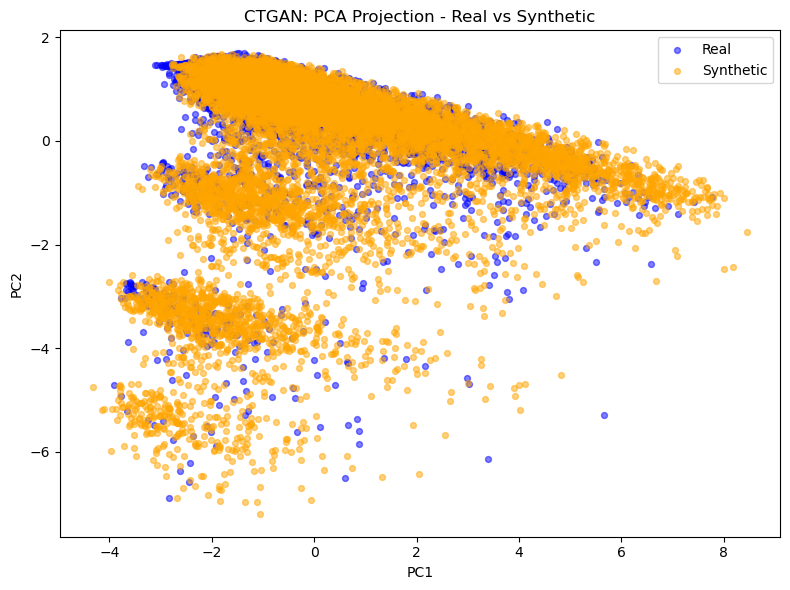

CTGAN - Two-Sample Classifier Accuracy: 0.7991

CopulaGAN - Global MMD (RBF): 0.013833


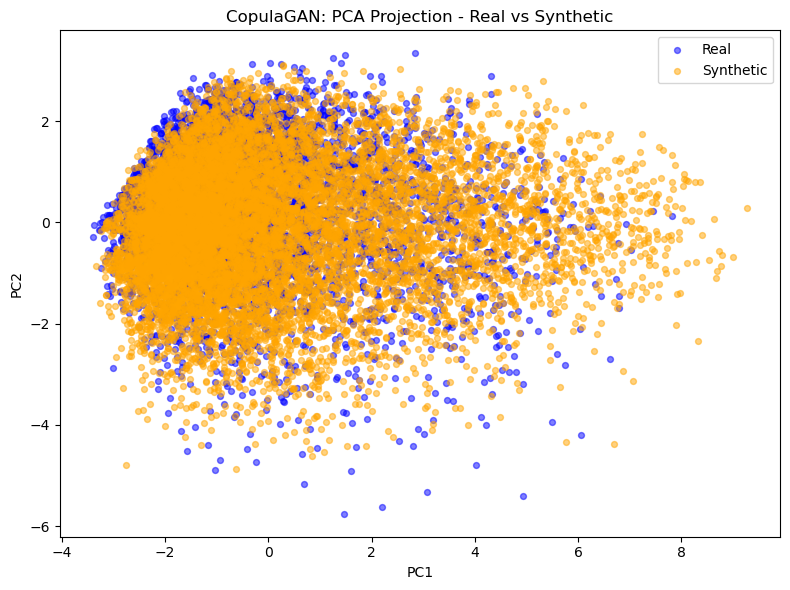

CopulaGAN - Two-Sample Classifier Accuracy: 0.7818

TVAE - Global MMD (RBF): 0.015303


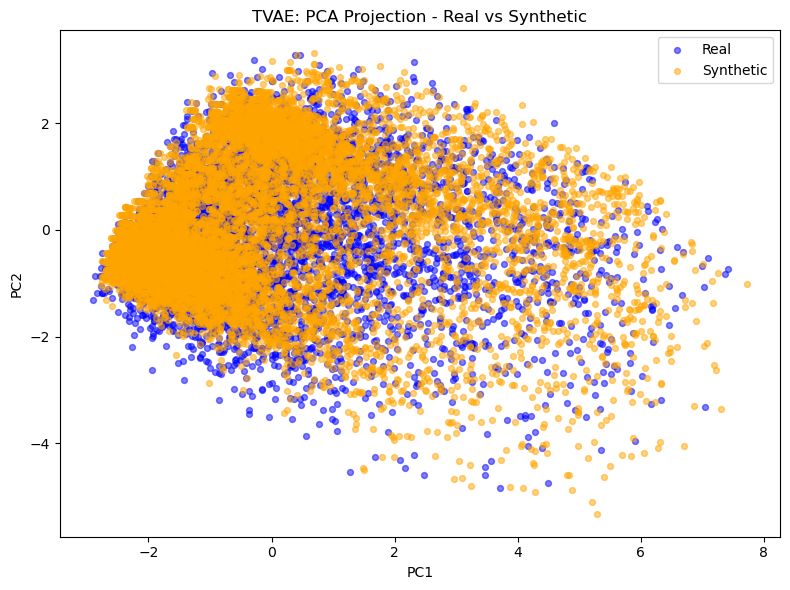

TVAE - Two-Sample Classifier Accuracy: 0.8391

GaussianCopula - Global MMD (RBF): 0.040098


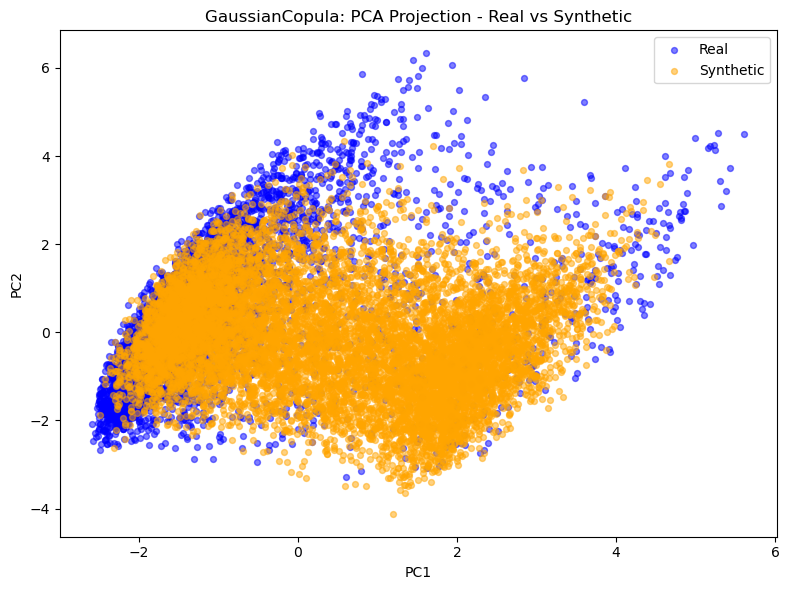

GaussianCopula - Two-Sample Classifier Accuracy: 0.8702

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,CopulaGAN,0.013833,0.781778
1,TVAE,0.015303,0.839111
2,CTGAN,0.017494,0.799111
3,GaussianCopula,0.040098,0.870222


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def mmd_rbf(X, Y, gamma=None, gamma_sample_size=1500):
    if gamma is None:
        Z = np.vstack([X, Y])
        n = len(Z)
        k = min(gamma_sample_size, n)
        idx = np.random.default_rng(42).choice(n, size=k, replace=False)
        Zs = Z[idx]
        d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
        vals = d2[np.triu_indices_from(d2, k=1)]
        med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
        gamma = 1.0 / (2.0 * med)

    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)

    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean())

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "Diabetes_binary"
id_col = "ID"
drop_cols = [c for c in [id_col, target_col] if c in data.columns]

X_real_df = data.drop(columns=drop_cols, errors="ignore").copy()
results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    X_synth_df = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = X_real_df.columns.intersection(X_synth_df.columns)
    X_real = X_real_df[common_cols].to_numpy(dtype=np.float64)
    X_synth = X_synth_df[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[labels == "Real", 0], X_pca[labels == "Real", 1],
                color="blue", alpha=0.5, label="Real", s=18)
    plt.scatter(X_pca[labels == "Synthetic", 0], X_pca[labels == "Synthetic", 1],
                color="orange", alpha=0.5, label="Synthetic", s=18)
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))
    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=42
    )

    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": float(mmd_value),
        "C2ST_Accuracy": float(acc)
    })

results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)

# 4 Utility with 10 classifiers 

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


models = { 

    'LogReg': LogisticRegression(max_iter=5000, solver='liblinear', random_state=42),
    'SVM-RBF': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'ExtraTrees':  ExtraTreesClassifier(random_state=42),
    'GradientBoost': GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=2000, random_state=42),
}

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate_models(train_df, test_df, label_col, models, test_size=0.2, seed=42):
    # Split TRAIN df -> (train part only)  (we don’t need train_df's test split)
    X_train = train_df.drop(columns=[label_col])
    y_train = train_df[label_col]

    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, test_size=test_size, random_state=seed, stratify=y_train
    )

    # Split TEST df -> (test part only)
    X_test = test_df.drop(columns=[label_col])
    y_test = test_df[label_col]

    _, X_test, _, y_test = train_test_split(
        X_test, y_test, test_size=test_size, random_state=seed, stratify=y_test
    )

    # Scale using TRAIN statistics only
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s  = scaler.transform(X_test)

    rows = []
    for name, clf in models.items():
        clf.fit(X_train_s, y_train)

        y_pred = clf.predict(X_test_s)

        # AUC needs probabilities (or decision_function); handle both safely
        if hasattr(clf, "predict_proba"):
            y_prob = clf.predict_proba(X_test_s)[:, 1]
        elif hasattr(clf, "decision_function"):
            scores = clf.decision_function(X_test_s)
            # convert to 0-1-ish range (not perfect prob, but works for AUC)
            y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
        else:
            y_prob = None

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred)

        auc = roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan")

        rows.append({"Model": name, "Accuracy": acc, "F1": f1, "AUC": auc})

    return pd.DataFrame(rows).sort_values(by="AUC", ascending=False)

In [46]:
import pandas as pd

label_col = "Diabetes_binary"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=data,
    test_df=data,
    label_col=label_col,
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comparisons = []

for synth_name in model_order:
    synth_train = synthetic_datasets[synth_name][data.columns].copy()

    tstr_results = evaluate_models(
        train_df=synth_train,
        test_df=data,
        label_col=label_col,
        models=models
    )

    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )

    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]

    if "F1_TRTR" in comparison.columns and "F1_TSTR" in comparison.columns:
        comparison["F1_Drop"] = comparison["F1_TRTR"] - comparison["F1_TSTR"]
    if "Accuracy_TRTR" in comparison.columns and "Accuracy_TSTR" in comparison.columns:
        comparison["Accuracy_Drop"] = comparison["Accuracy_TRTR"] - comparison["Accuracy_TSTR"]

    comparison["Synthetic_Model"] = synth_name
    comparison = comparison.sort_values("AUC_Drop", ascending=False)

    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)

    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)

summary = (combined_comparison
           .groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
           .mean()
           .sort_values("AUC_Drop"))

print("Average AUC drop by synthetic generator (lower is better):")
display(summary)

TRTR (Train Real, Test Real)


,Model,Accuracy,F1,AUC
8,AdaBoost,0.856,0.191011,0.803268
0,LogReg,0.858,0.154762,0.801952
7,GradientBoost,0.858,0.123457,0.793978
5,RandomForest,0.855,0.099379,0.770705
6,ExtraTrees,0.849,0.116959,0.753300
3,NaiveBayes,0.740,0.359606,0.743872
1,SVM-RBF,0.858,0.040541,0.697628
9,MLP,0.832,0.300000,0.674678
2,KNN,0.842,0.177083,0.665166
4,DecisionTree,0.786,0.267123,0.574599


CTGAN - TSTR (Train Synthetic, Test Real)


,Model,Accuracy,F1,AUC
8,AdaBoost,0.842,0.150538,0.764858
0,LogReg,0.846,0.144444,0.761130
3,NaiveBayes,0.792,0.350000,0.750572
7,GradientBoost,0.844,0.142857,0.750042
5,RandomForest,0.835,0.098361,0.701478
6,ExtraTrees,0.839,0.110497,0.700511
9,MLP,0.828,0.211009,0.656882
2,KNN,0.823,0.169014,0.640602
1,SVM-RBF,0.841,0.080925,0.593278
4,DecisionTree,0.771,0.218430,0.544596


CTGAN - TRTR vs TSTR Comparison


...

,Model,Accuracy,F1,AUC
0,LogReg,0.863,0.014388,0.769402
8,AdaBoost,0.862,0.000000,0.748394
3,NaiveBayes,0.828,0.218182,0.748176
7,GradientBoost,0.858,0.013889,0.741615
5,RandomForest,0.862,0.000000,0.671984
6,ExtraTrees,0.863,0.014388,0.640510
1,SVM-RBF,0.862,0.000000,0.587091
2,KNN,0.847,0.061350,0.551679
4,DecisionTree,0.746,0.220859,0.542268
9,MLP,0.821,0.135266,0.530995


GaussianCopula - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,F1_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,AUC_TSTR,AUC_Drop,F1_Drop,Accuracy_Drop,Synthetic_Model
7,MLP,0.832,0.300000,0.674678,0.821,0.135266,0.530995,0.143683,0.164734,0.011,GaussianCopula
8,KNN,0.842,0.177083,0.665166,0.847,0.061350,0.551679,0.113487,0.115734,-0.005,GaussianCopula
4,ExtraTrees,0.849,0.116959,0.753300,0.863,0.014388,0.640510,0.112790,0.102571,-0.014,GaussianCopula
6,SVM-RBF,0.858,0.040541,0.697628,0.862,0.000000,0.587091,0.110537,0.040541,-0.004,GaussianCopula
3,RandomForest,0.855,0.099379,0.770705,0.862,0.000000,0.671984,0.098721,0.099379,-0.007,GaussianCopula
0,AdaBoost,0.856,0.191011,0.803268,0.862,0.000000,0.748394,0.054873,0.191011,-0.006,GaussianCopula
2,GradientBoost,0.858,0.123457,0.793978,0.858,0.013889,0.741615,0.052364,0.109568,0.000,GaussianCopula
1,LogReg,0.858,0.154762,0.801952,0.863,0.014388,0.769402,0.032550,0.140373,-0.005,GaussianCopula
9,DecisionTree,0.786,0.267123,0.574599,0.746,0.220859,0.542268,0.032331,0.046264,0.040,GaussianCopula
5,NaiveBayes,0.740,0.359606,0.743872,0.828,0.218182,0.748176,-0.004304,0.141424,-0.088,GaussianCopula


Average AUC drop by synthetic generator (lower is better):


,Synthetic_Model,AUC_Drop
3,TVAE,0.001299
1,CopulaGAN,0.022946
0,CTGAN,0.041520
2,GaussianCopula,0.074703



CTGAN - TSTR


,Model,Accuracy,F1,AUC
8,AdaBoost,0.842,0.150538,0.764858
0,LogReg,0.846,0.144444,0.761130
3,NaiveBayes,0.792,0.350000,0.750572
7,GradientBoost,0.844,0.142857,0.750042
5,RandomForest,0.835,0.098361,0.701478
6,ExtraTrees,0.839,0.110497,0.700511
9,MLP,0.828,0.211009,0.656882
2,KNN,0.823,0.169014,0.640602
1,SVM-RBF,0.841,0.080925,0.593278
4,DecisionTree,0.771,0.218430,0.544596


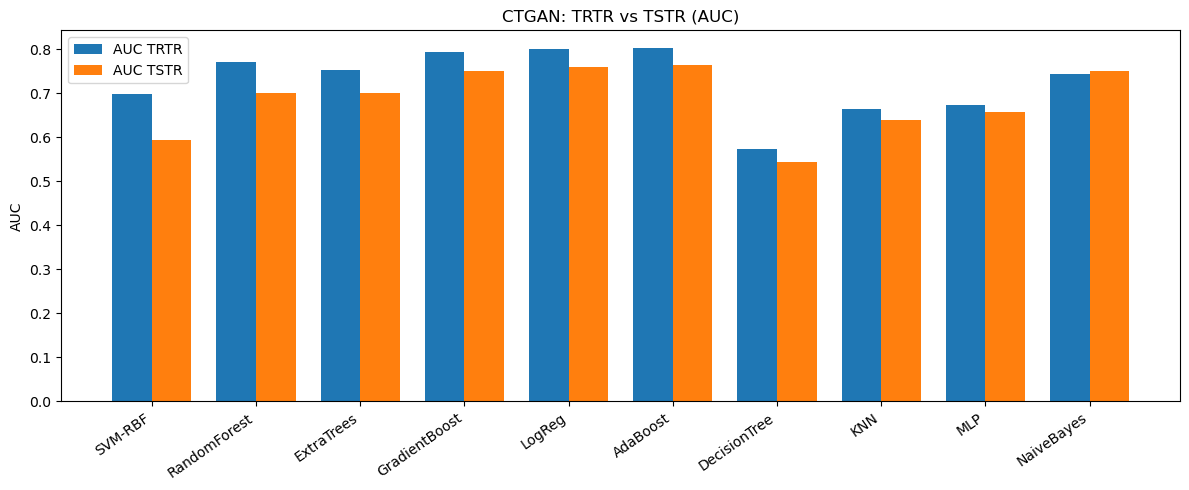

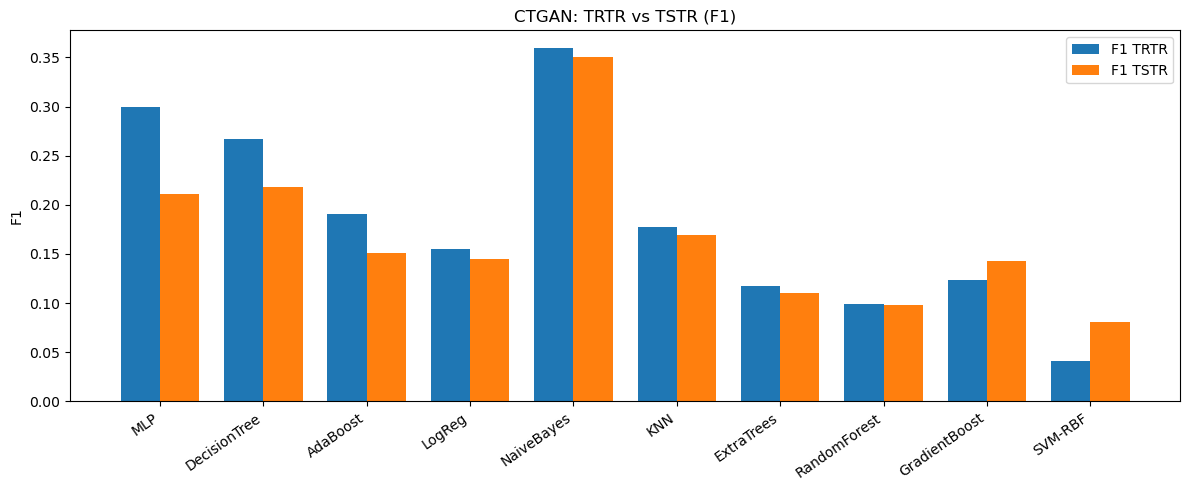

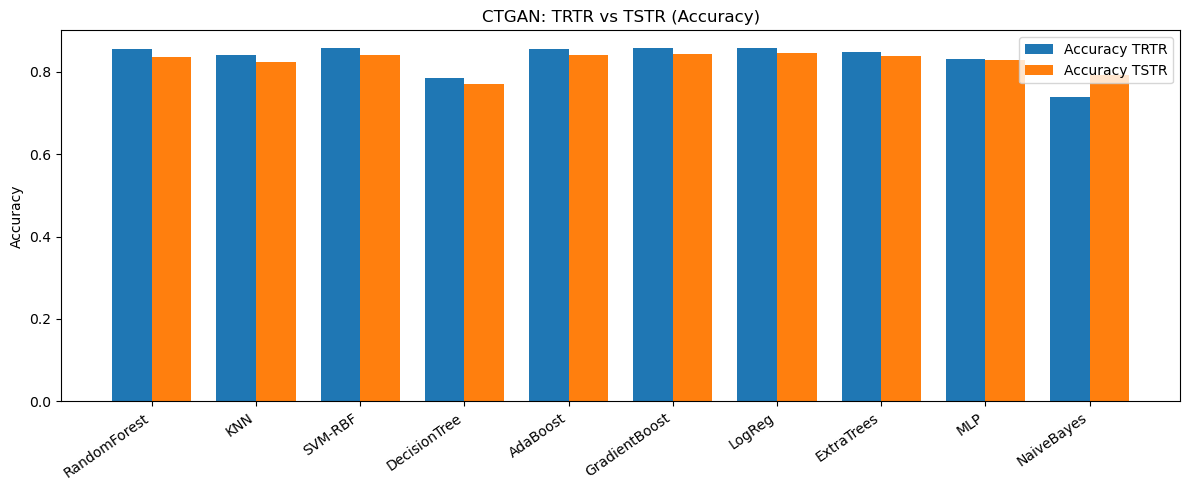

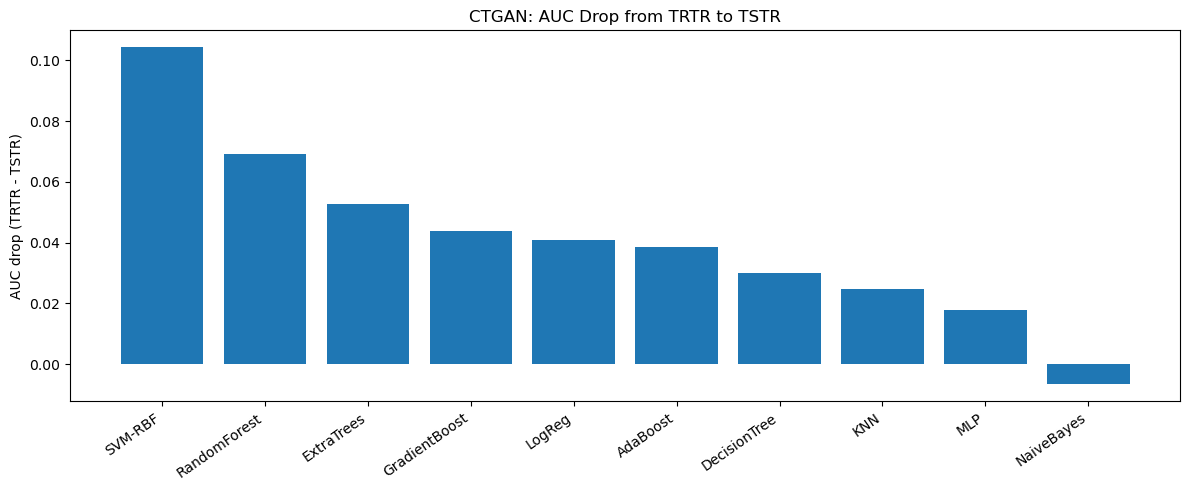


CopulaGAN - TSTR


,Model,Accuracy,F1,AUC
0,LogReg,0.839,0.244131,0.763114
7,GradientBoost,0.826,0.223214,0.751185
8,AdaBoost,0.826,0.250000,0.748764
3,NaiveBayes,0.755,0.325069,0.725499
5,RandomForest,0.831,0.199052,0.725272
6,ExtraTrees,0.820,0.210526,0.723406
9,MLP,0.807,0.266160,0.692449
2,KNN,0.814,0.279070,0.691634
1,SVM-RBF,0.826,0.216216,0.655377
4,DecisionTree,0.736,0.266667,0.572985


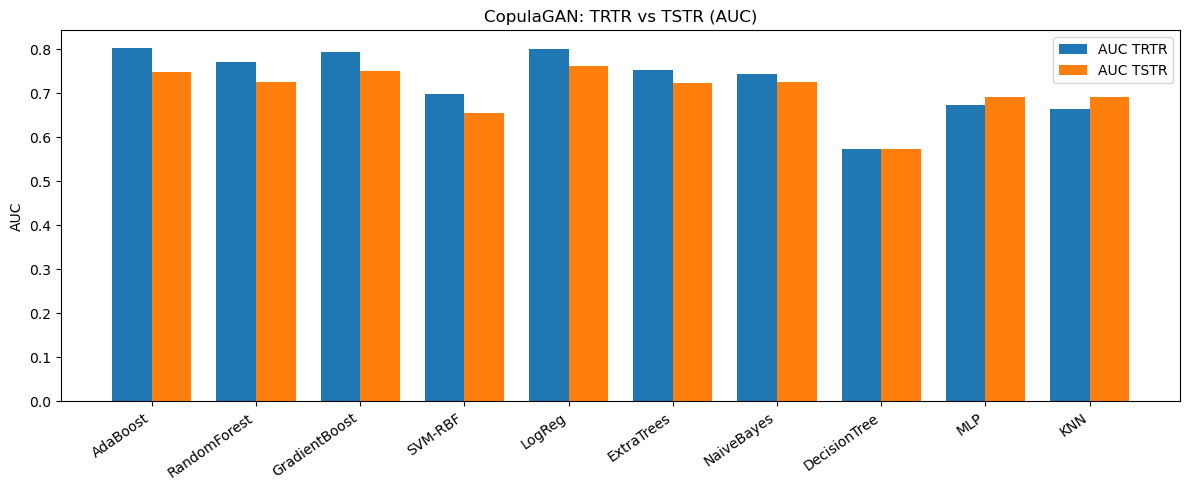

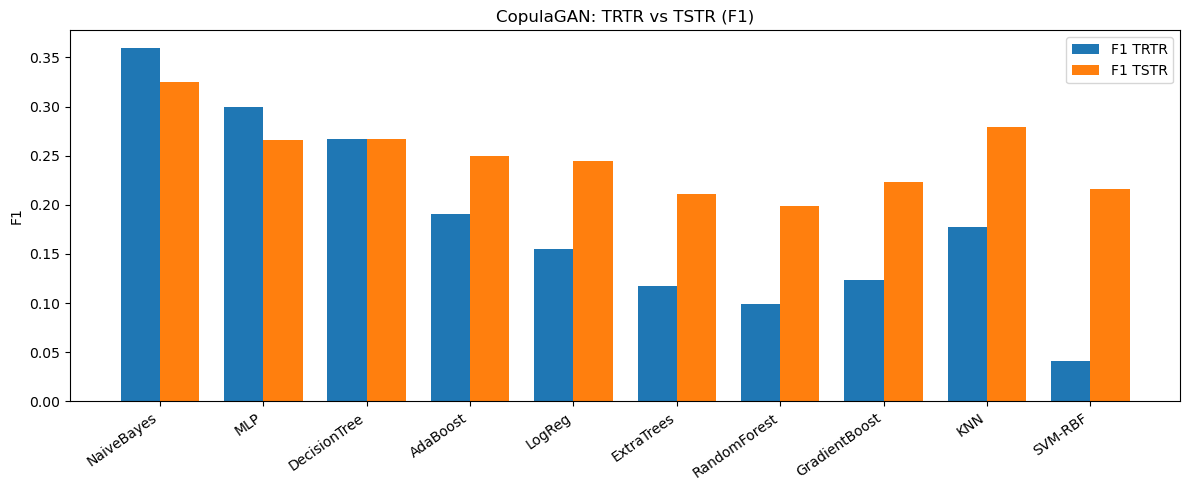

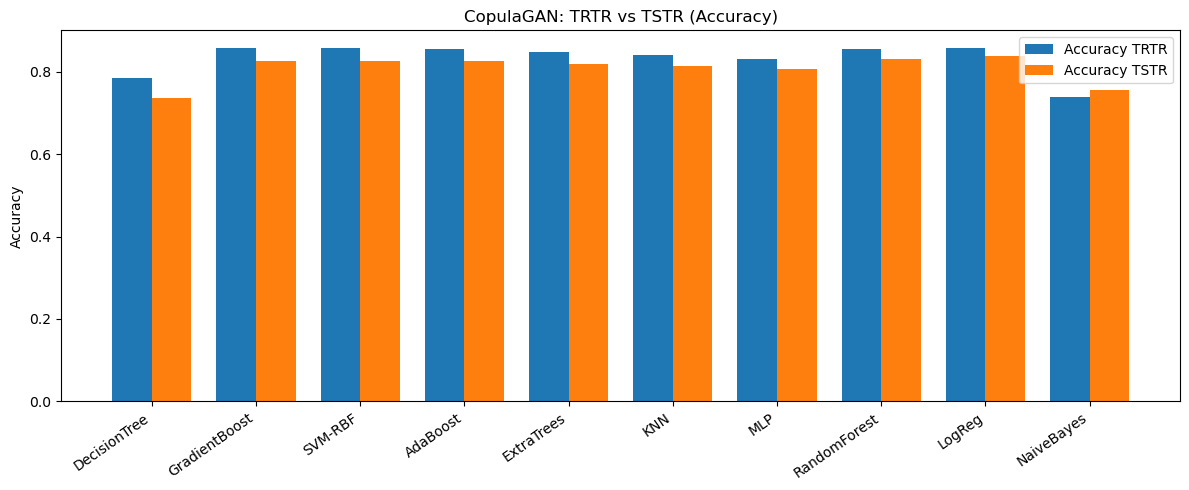

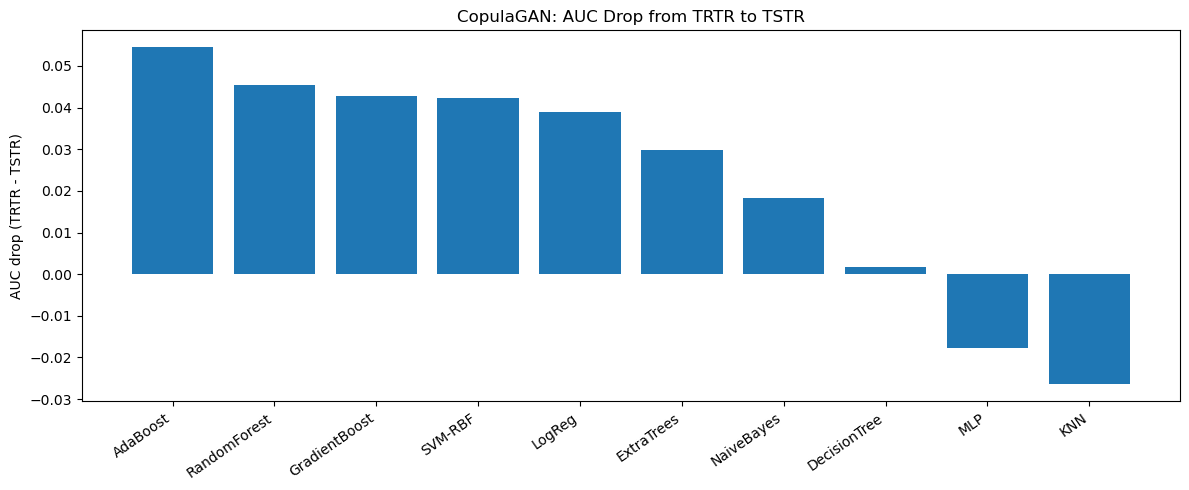


TVAE - TSTR


,Model,Accuracy,F1,AUC
0,LogReg,0.846,0.214286,0.791587
7,GradientBoost,0.847,0.274882,0.791293
8,AdaBoost,0.857,0.133333,0.779818
5,RandomForest,0.857,0.209945,0.761803
6,ExtraTrees,0.856,0.200000,0.748201
9,MLP,0.852,0.295238,0.735331
1,SVM-RBF,0.853,0.213904,0.703739
3,NaiveBayes,0.692,0.366255,0.692264
2,KNN,0.838,0.242991,0.668087
4,DecisionTree,0.830,0.303279,0.594035


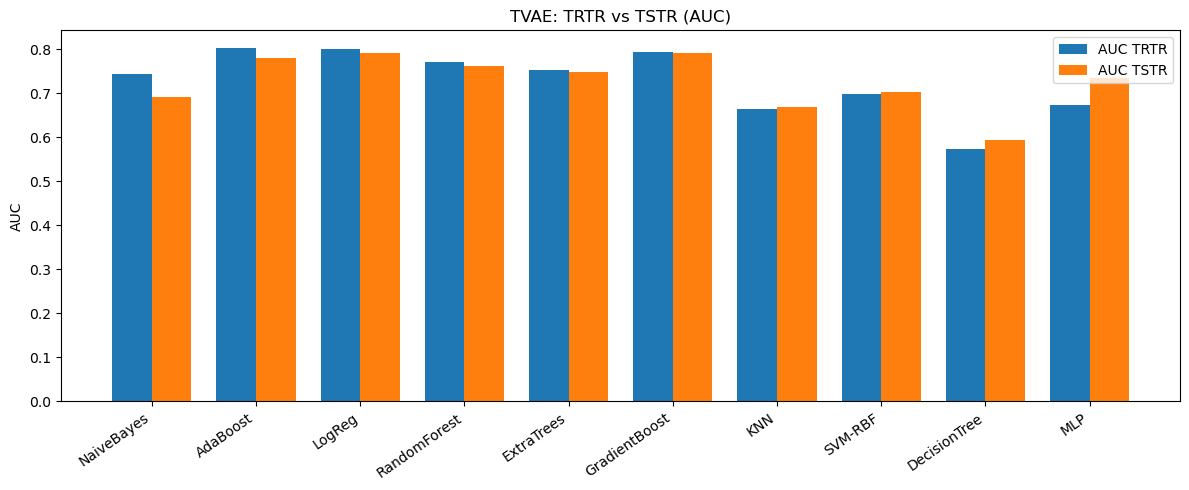

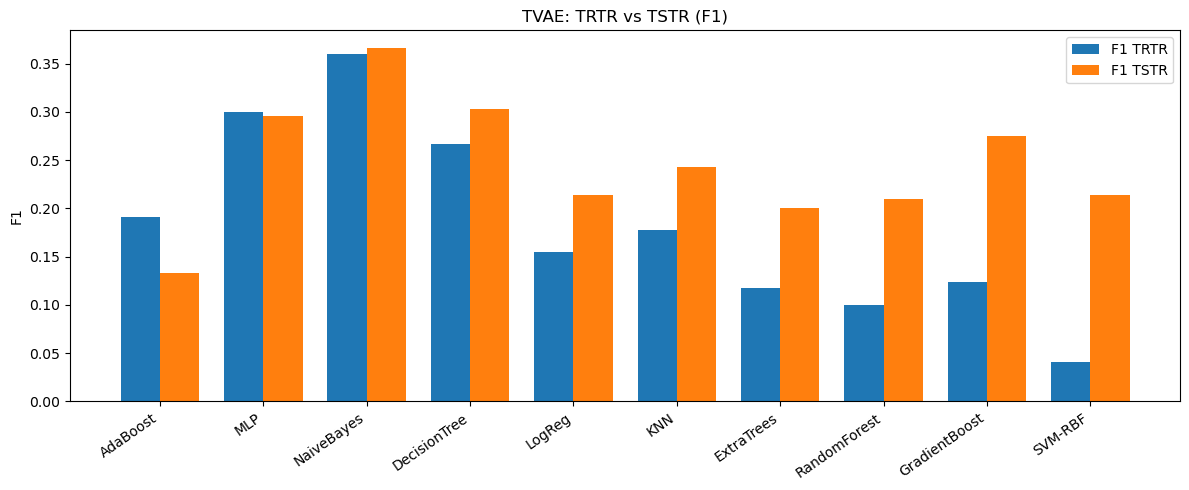

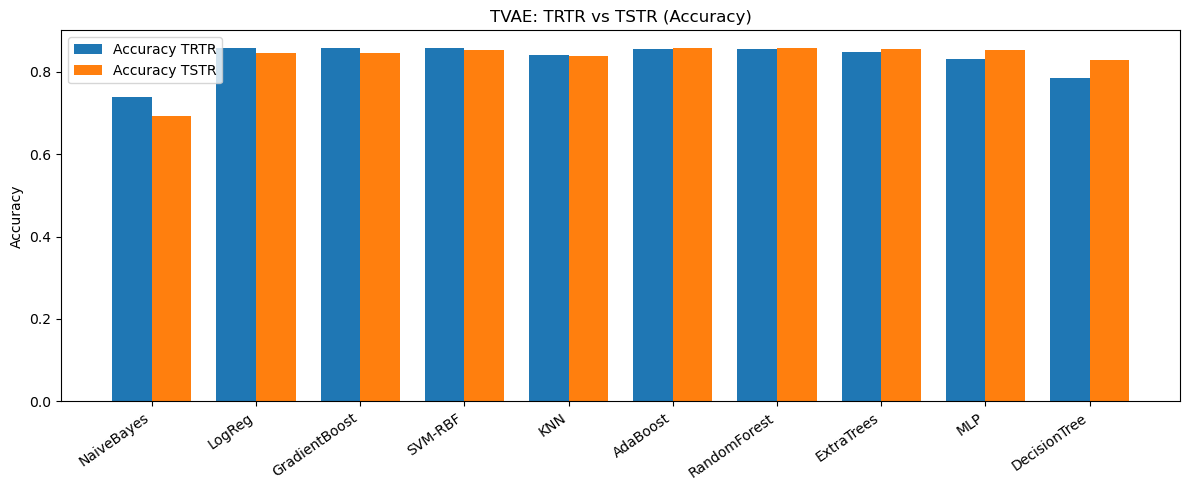

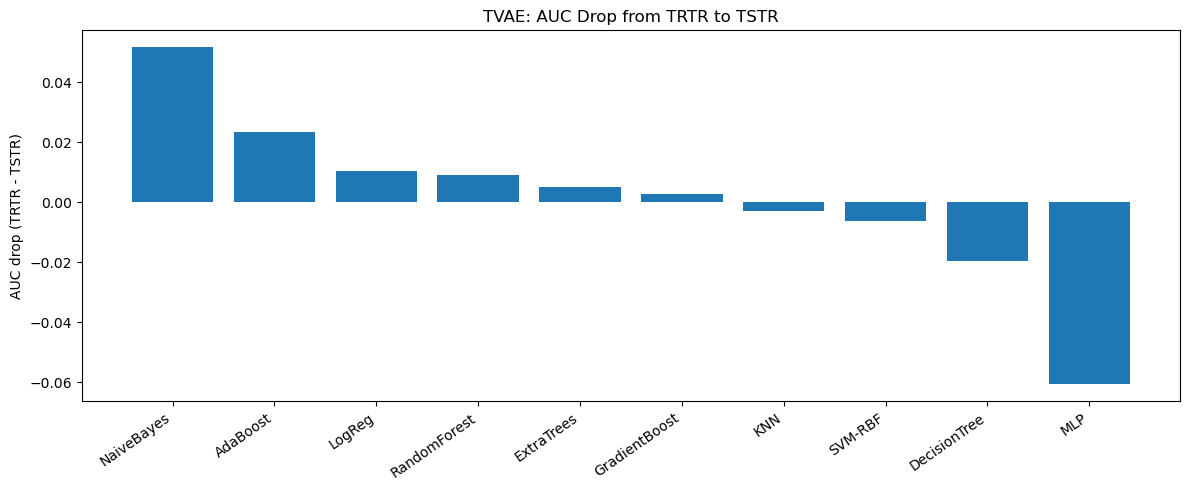


GaussianCopula - TSTR


,Model,Accuracy,F1,AUC
0,LogReg,0.863,0.014388,0.769402
8,AdaBoost,0.862,0.000000,0.748394
3,NaiveBayes,0.828,0.218182,0.748176
7,GradientBoost,0.858,0.013889,0.741615
5,RandomForest,0.862,0.000000,0.671984
6,ExtraTrees,0.863,0.014388,0.640510
1,SVM-RBF,0.862,0.000000,0.587091
2,KNN,0.847,0.061350,0.551679
4,DecisionTree,0.746,0.220859,0.542268
9,MLP,0.821,0.135266,0.530995


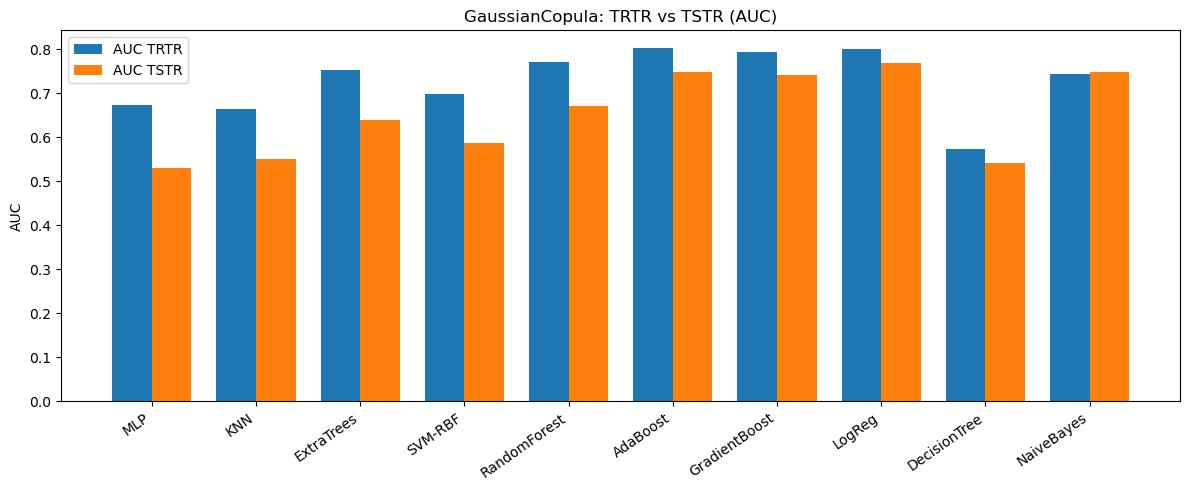

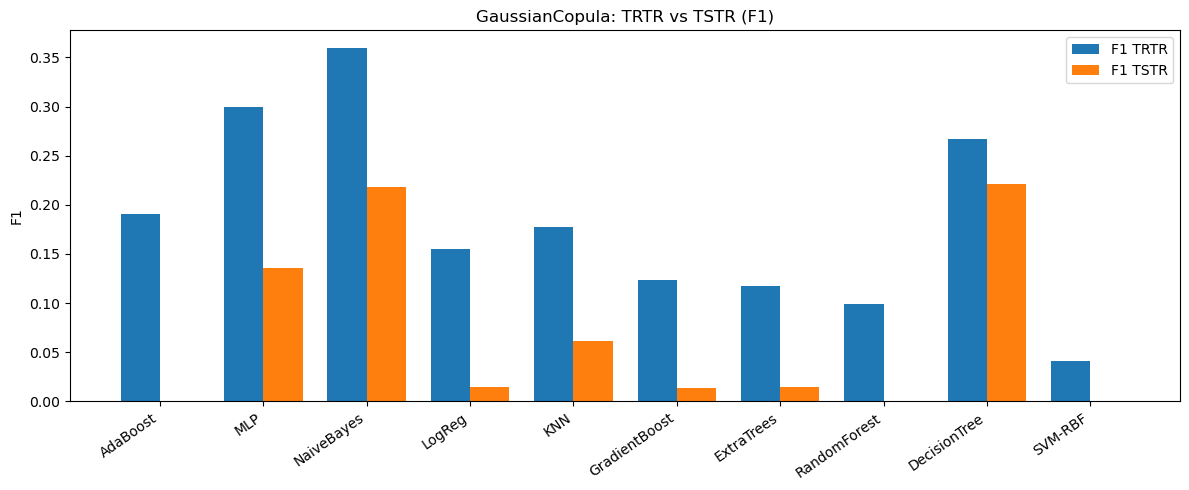

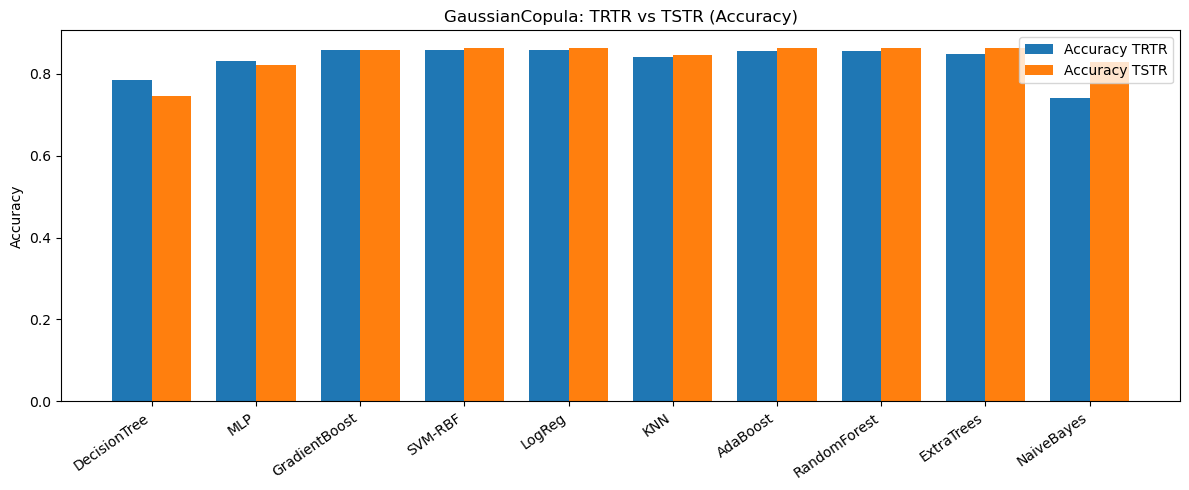

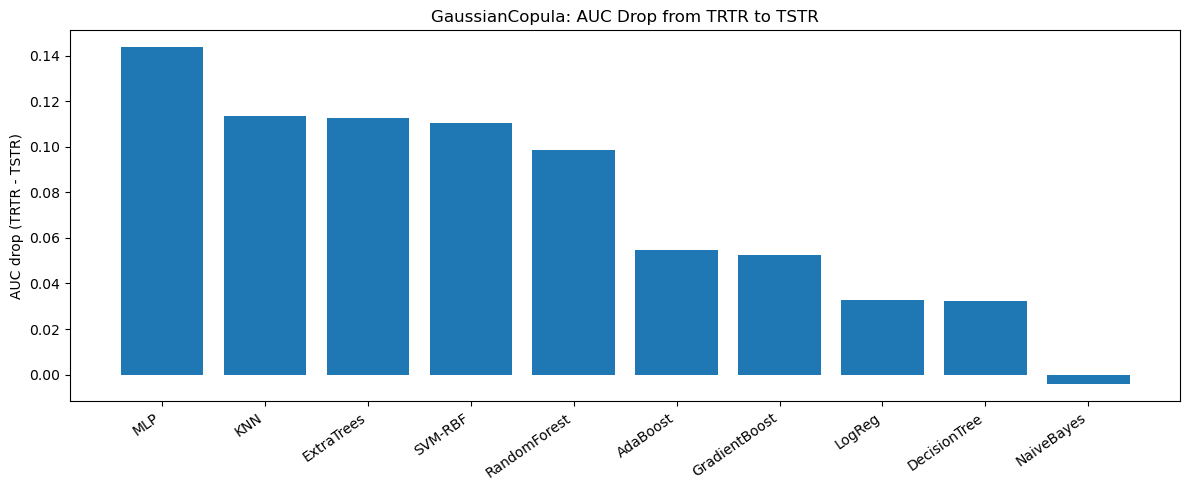


Average AUC drop by synthetic generator:


,Synthetic_Model,AUC_Drop
3,TVAE,0.001299
1,CopulaGAN,0.022946
0,CTGAN,0.041520
2,GaussianCopula,0.074703


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="AUC"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )
    df["Drop"] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    df = df.sort_values("Drop", ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w/2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w/2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_auc_drop(comparison_df, synth_name):
    if "AUC_Drop" not in comparison_df.columns:
        return

    df = comparison_df.sort_values("AUC_Drop", ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df["AUC_Drop"])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel("AUC drop (TRTR - TSTR)")
    plt.title(f"{synth_name}: AUC Drop from TRTR to TSTR")
    plt.tight_layout()
    plt.show()

label_col = "Diabetes_binary"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=data,
    test_df=data,
    label_col=label_col,
    models=models
)

all_comp = []

for synth_name in model_order:
    synth_train = synthetic_datasets[synth_name][data.columns].copy()

    tstr_results = evaluate_models(
        train_df=synth_train,
        test_df=data,
        label_col=label_col,
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )
    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
    comparison["Synthetic_Model"] = synth_name
    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR")
    display(tstr_results)

    for metric in ["AUC", "F1", "Accuracy"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric=metric)

    plot_auc_drop(comparison, synth_name)

combined_comparison = pd.concat(all_comp, ignore_index=True)

summary_auc = (combined_comparison.groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
               .mean()
               .sort_values("AUC_Drop"))

print("\nAverage AUC drop by synthetic generator:")
display(summary_auc)


CTGAN - TSTR


,Model,Accuracy,F1,AUC
8,AdaBoost,0.842,0.150538,0.764858
0,LogReg,0.846,0.144444,0.761130
3,NaiveBayes,0.792,0.350000,0.750572
7,GradientBoost,0.844,0.142857,0.750042
5,RandomForest,0.835,0.098361,0.701478
6,ExtraTrees,0.839,0.110497,0.700511
9,MLP,0.828,0.211009,0.656882
2,KNN,0.823,0.169014,0.640602
1,SVM-RBF,0.841,0.080925,0.593278
4,DecisionTree,0.771,0.218430,0.544596


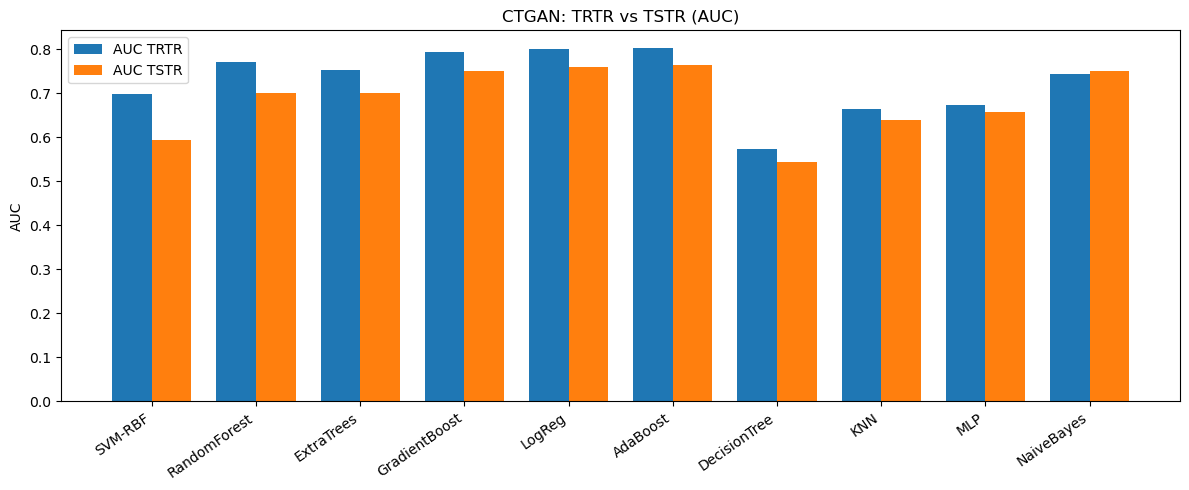

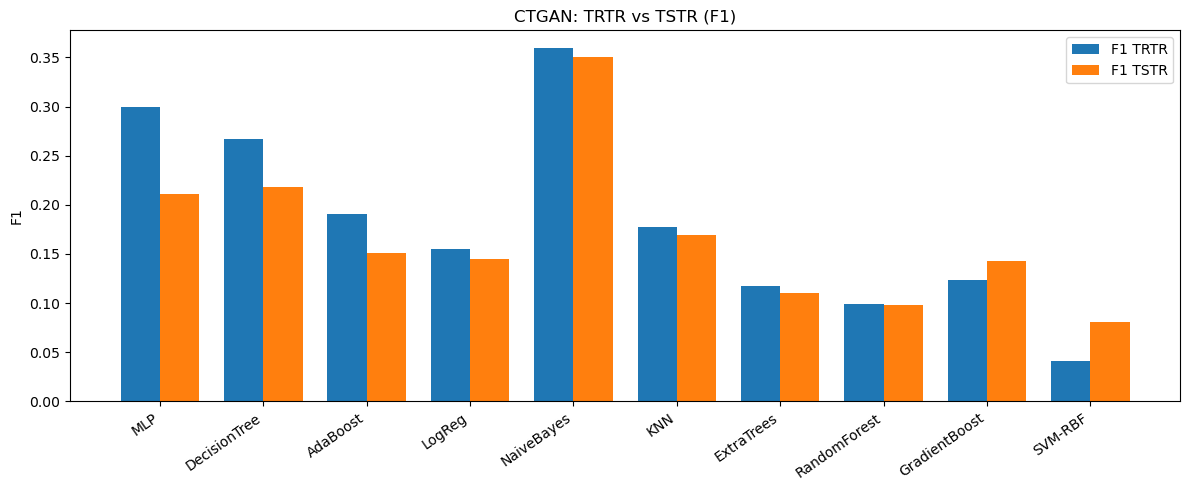

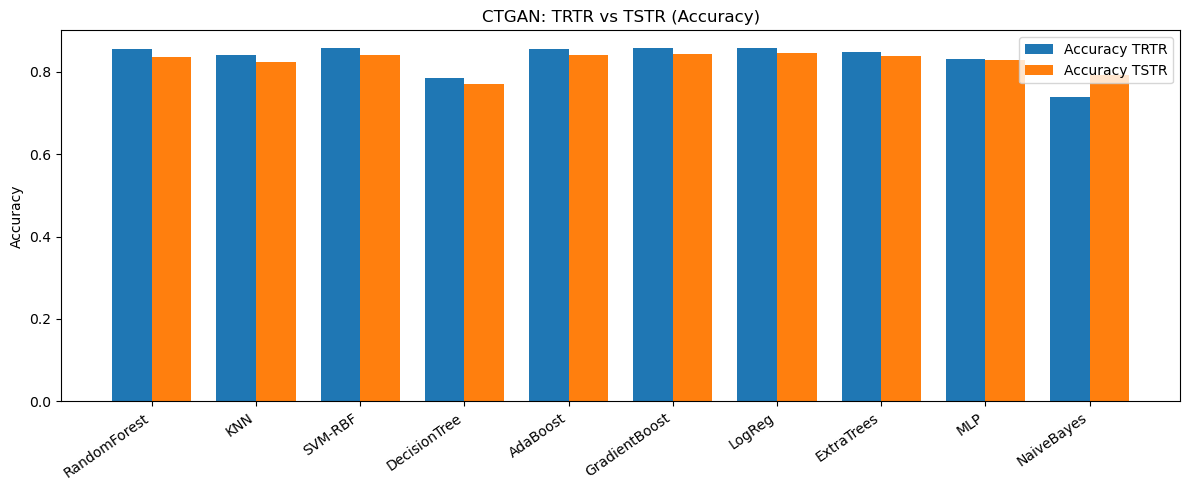

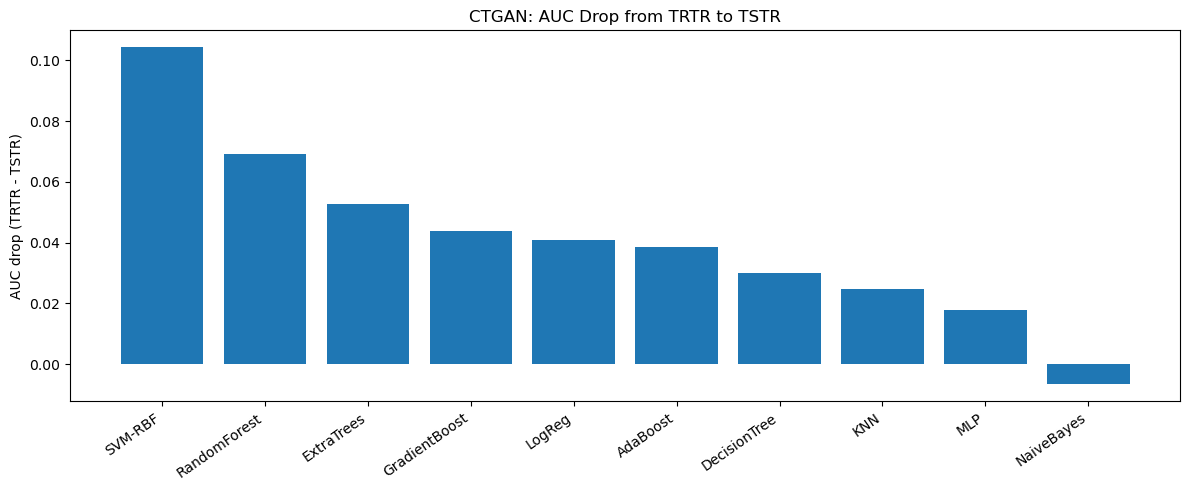


CopulaGAN - TSTR


,Model,Accuracy,F1,AUC
0,LogReg,0.839,0.244131,0.763114
7,GradientBoost,0.826,0.223214,0.751185
8,AdaBoost,0.826,0.250000,0.748764
3,NaiveBayes,0.755,0.325069,0.725499
5,RandomForest,0.831,0.199052,0.725272
6,ExtraTrees,0.820,0.210526,0.723406
9,MLP,0.807,0.266160,0.692449
2,KNN,0.814,0.279070,0.691634
1,SVM-RBF,0.826,0.216216,0.655377
4,DecisionTree,0.736,0.266667,0.572985


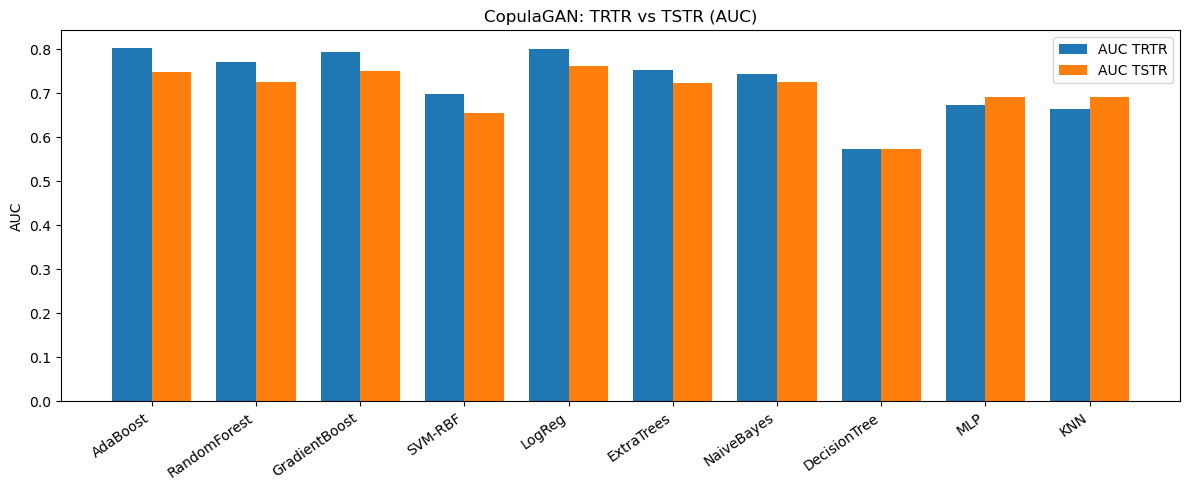

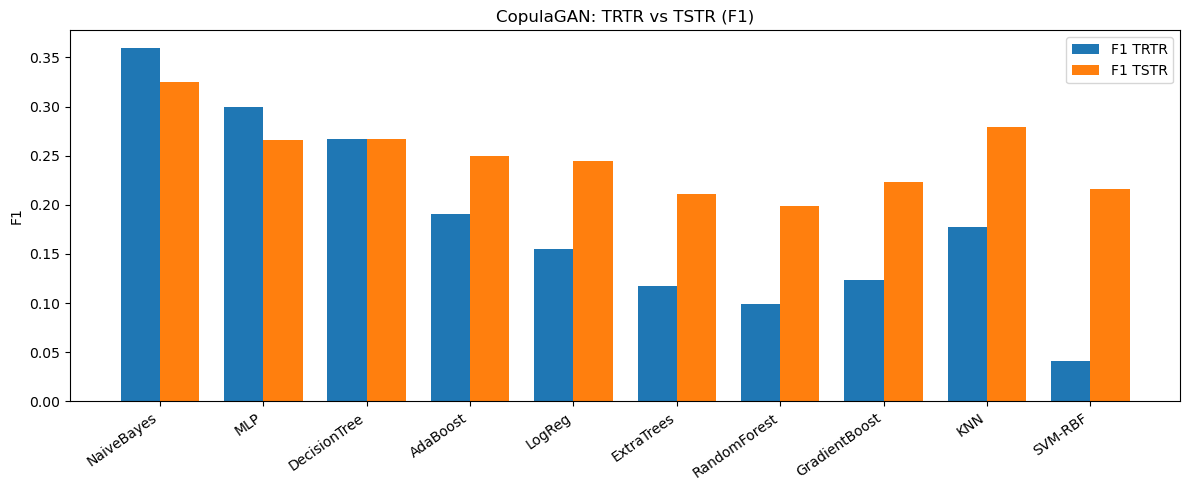

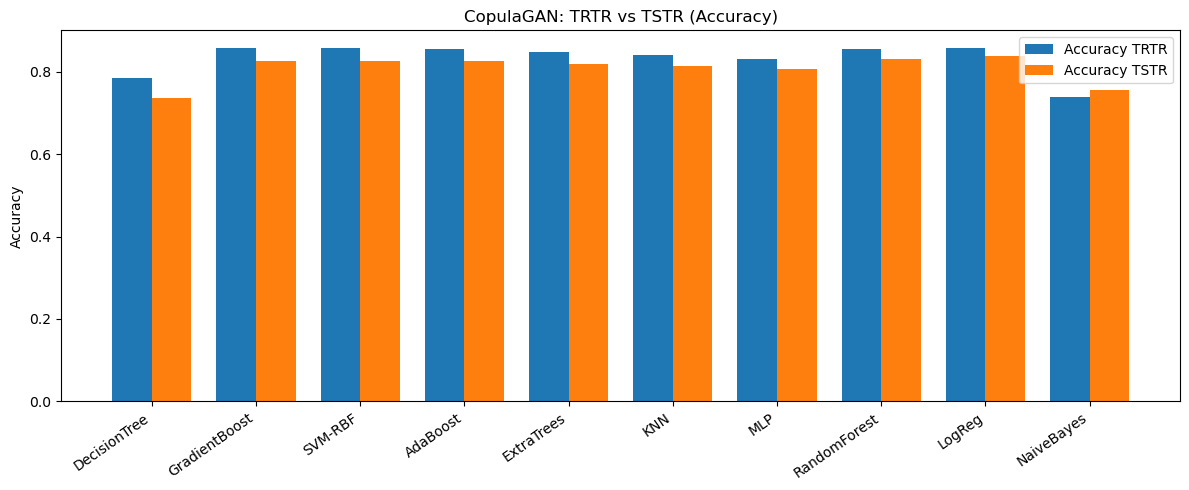

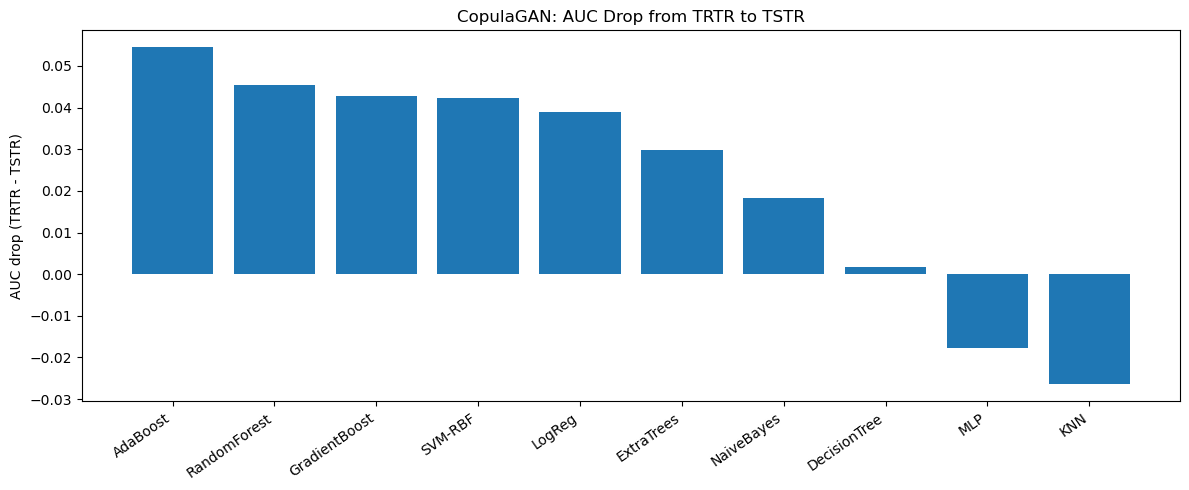


TVAE - TSTR


,Model,Accuracy,F1,AUC
0,LogReg,0.846,0.214286,0.791587
7,GradientBoost,0.847,0.274882,0.791293
8,AdaBoost,0.857,0.133333,0.779818
5,RandomForest,0.857,0.209945,0.761803
6,ExtraTrees,0.856,0.200000,0.748201
9,MLP,0.852,0.295238,0.735331
1,SVM-RBF,0.853,0.213904,0.703739
3,NaiveBayes,0.692,0.366255,0.692264
2,KNN,0.838,0.242991,0.668087
4,DecisionTree,0.830,0.303279,0.594035


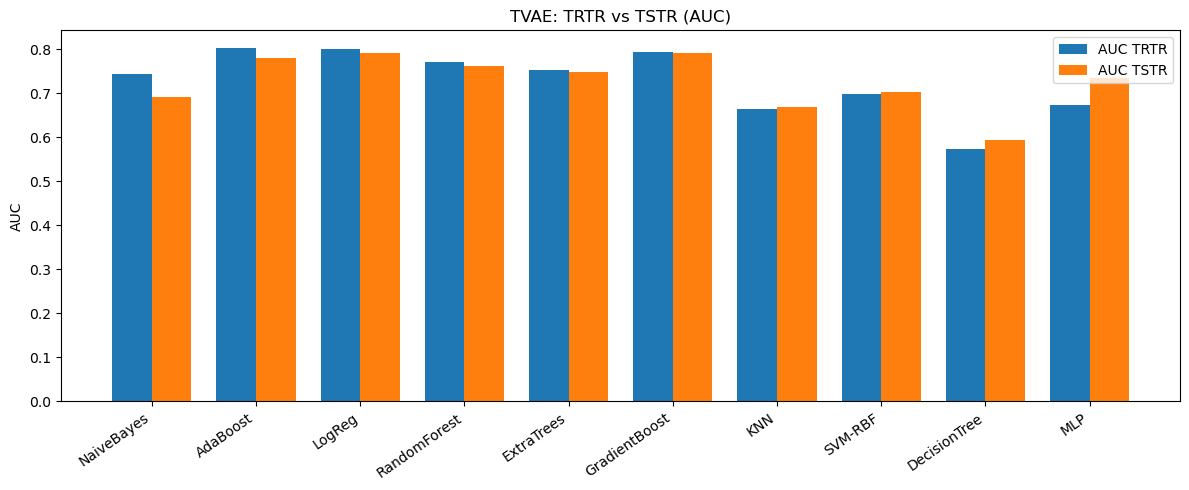

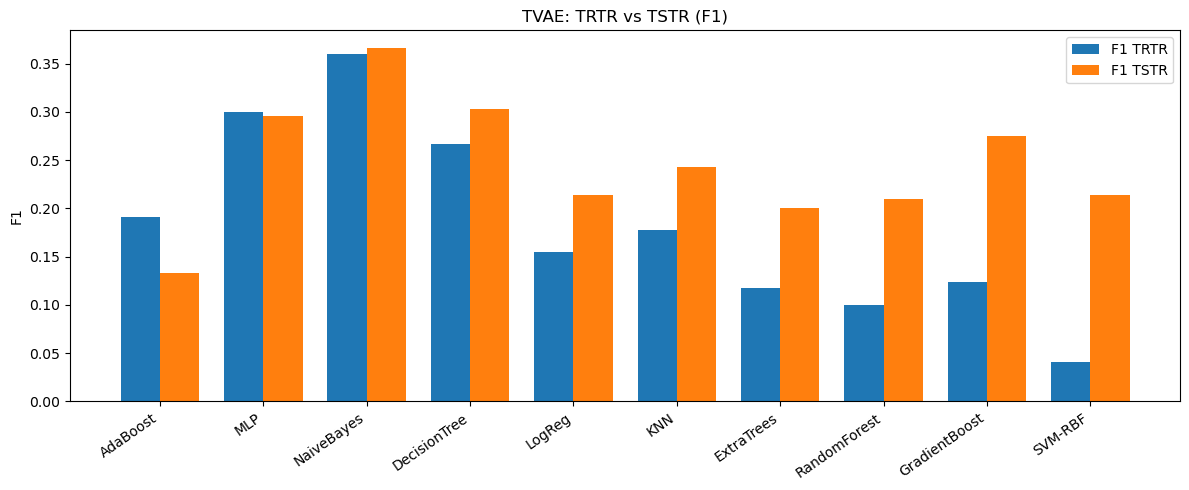

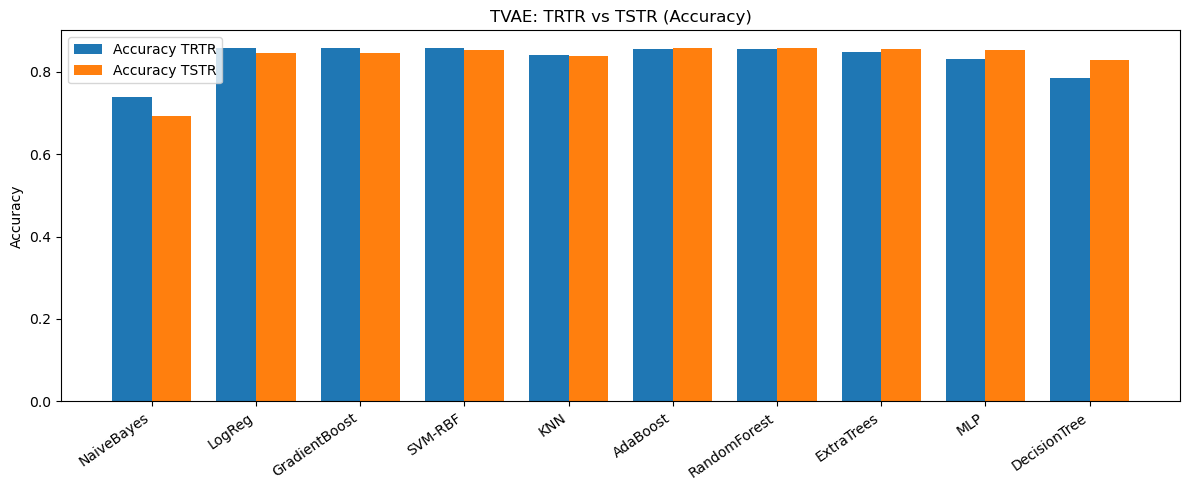

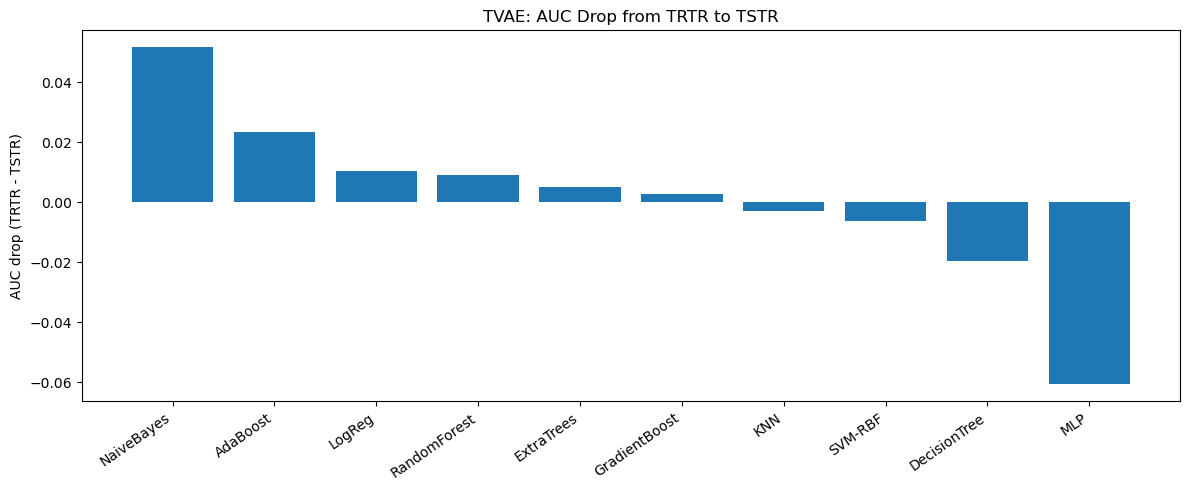


GaussianCopula - TSTR


,Model,Accuracy,F1,AUC
0,LogReg,0.863,0.014388,0.769402
8,AdaBoost,0.862,0.000000,0.748394
3,NaiveBayes,0.828,0.218182,0.748176
7,GradientBoost,0.858,0.013889,0.741615
5,RandomForest,0.862,0.000000,0.671984
6,ExtraTrees,0.863,0.014388,0.640510
1,SVM-RBF,0.862,0.000000,0.587091
2,KNN,0.847,0.061350,0.551679
4,DecisionTree,0.746,0.220859,0.542268
9,MLP,0.821,0.135266,0.530995


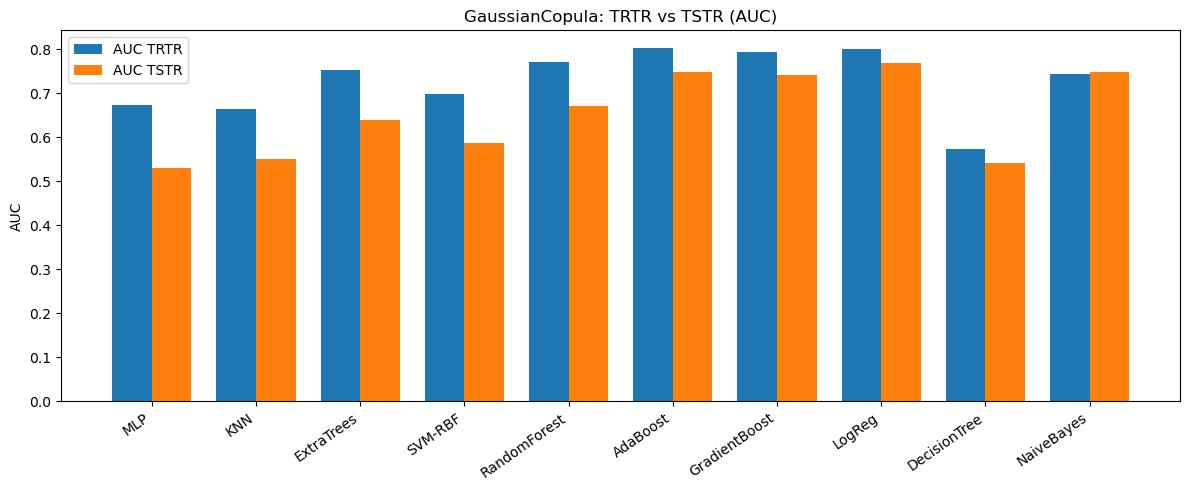

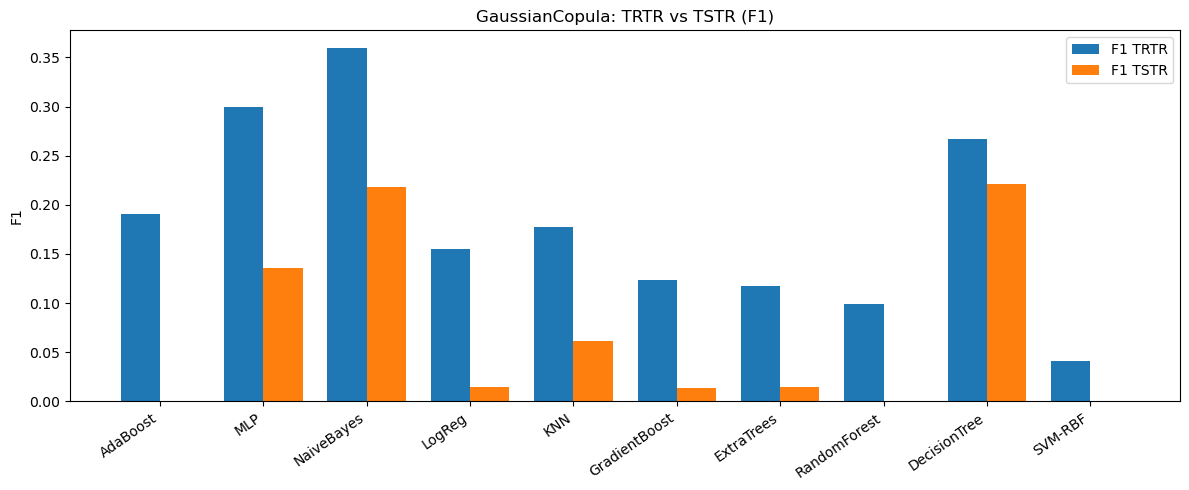

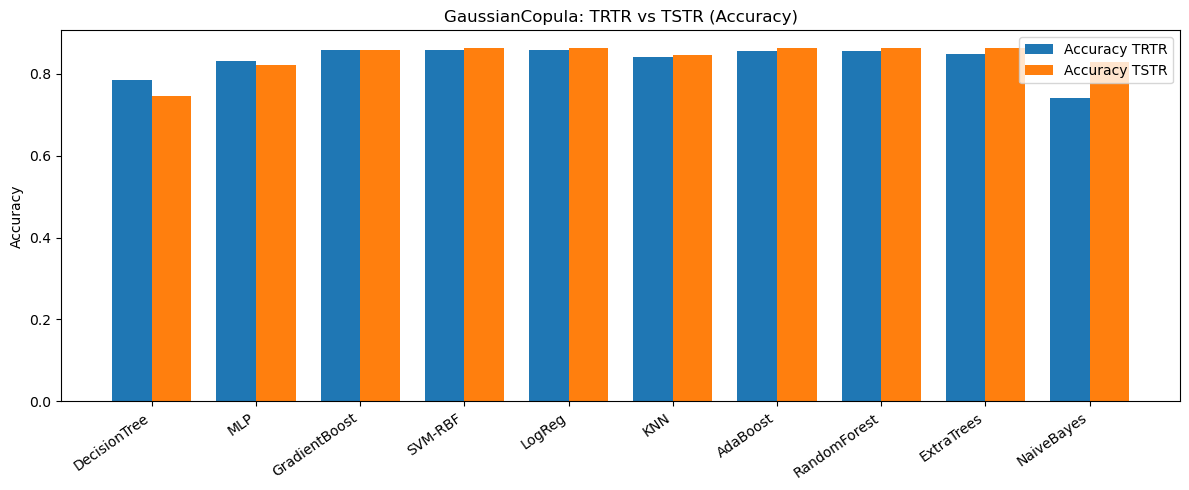

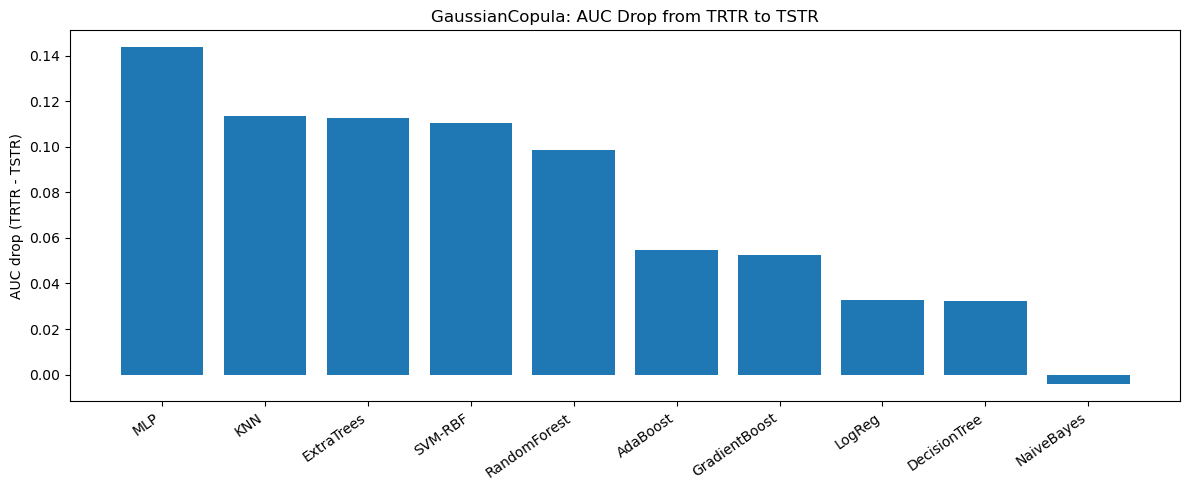


Average AUC drop by synthetic generator:


,Synthetic_Model,AUC_Drop
3,TVAE,0.001299
1,CopulaGAN,0.022946
0,CTGAN,0.041520
2,GaussianCopula,0.074703


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="AUC"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )
    df["Drop"] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    df = df.sort_values("Drop", ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w/2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w/2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_auc_drop(comparison_df, synth_name):
    if "AUC_Drop" not in comparison_df.columns:
        return

    df = comparison_df.sort_values("AUC_Drop", ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df["AUC_Drop"])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel("AUC drop (TRTR - TSTR)")
    plt.title(f"{synth_name}: AUC Drop from TRTR to TSTR")
    plt.tight_layout()
    plt.show()

label_col = "Diabetes_binary"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=data,
    test_df=data,
    label_col=label_col,
    models=models
)

all_comp = []

for synth_name in model_order:
    synth_train = synthetic_datasets[synth_name][data.columns].copy()

    tstr_results = evaluate_models(
        train_df=synth_train,
        test_df=data,
        label_col=label_col,
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )
    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
    comparison["Synthetic_Model"] = synth_name
    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR")
    display(tstr_results)

    for metric in ["AUC", "F1", "Accuracy"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric=metric)

    plot_auc_drop(comparison, synth_name)

combined_comparison = pd.concat(all_comp, ignore_index=True)

summary_auc = (combined_comparison.groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
               .mean()
               .sort_values("AUC_Drop"))

print("\nAverage AUC drop by synthetic generator:")
display(summary_auc)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results,
    generator_name,
    ncols=5
):
    metrics = [m for m in ["Accuracy", "F1", "AUC"] if m in trtr_results.columns and m in tstr_results.columns]
    if not metrics:
        print(f"No common metrics found for {generator_name}.")
        return

    x = np.arange(len(metrics))

    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models_local = [m for m in trtr.index if m in tstr.index]

    n = len(models_local)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(22, 9),
        dpi=150,
        constrained_layout=True
    )
    axes = np.array(axes).reshape(-1)

    for i, m in enumerate(models_local):
        ax = axes[i]
        a = trtr.loc[m].values.astype(float)
        b = tstr.loc[m].values.astype(float)
        d = a - b

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="o", label="TSTR")
        ax.fill_between(x, b, a, alpha=0.2)

        for xi, ai, bi, di in zip(x, a, b, d):
            ax.text(xi, (ai + bi) / 2, f"Δ={di:.3f}", ha="center", va="center", fontsize=8)

        ax.set_title(m, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        lo = float(np.nanmin(np.concatenate([a, b])))
        hi = float(np.nanmax(np.concatenate([a, b])))
        pad = max((hi - lo) * 0.15, 0.05) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)

        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="lower left")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{generator_name} - TRTR vs TSTR per classifier\n"
        f"Shaded area / Δ label = drop (TRTR - TSTR)",
        fontsize=14
    )
    plt.show()

label_col = "Diabetes_binary"
generators = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=data,
    test_df=data,
    label_col=label_col,
    models=models
)

for gen in generators:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[gen][data.columns],
        test_df=data,
        label_col=label_col,
        models=models
    )
    plot_grid_line_metrics_with_gap(
        trtr_results,
        tstr_results,
        generator_name=gen,
        ncols=5
    )


# 5 Statistical similarity tests 

Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,26.911364,10.844658,14.129601
1,CopulaGAN,20.300259,17.665094,10.617060
2,TVAE,20.710261,5.580357,24.812616
3,GaussianCopula,20.260145,0.893256,4.371937


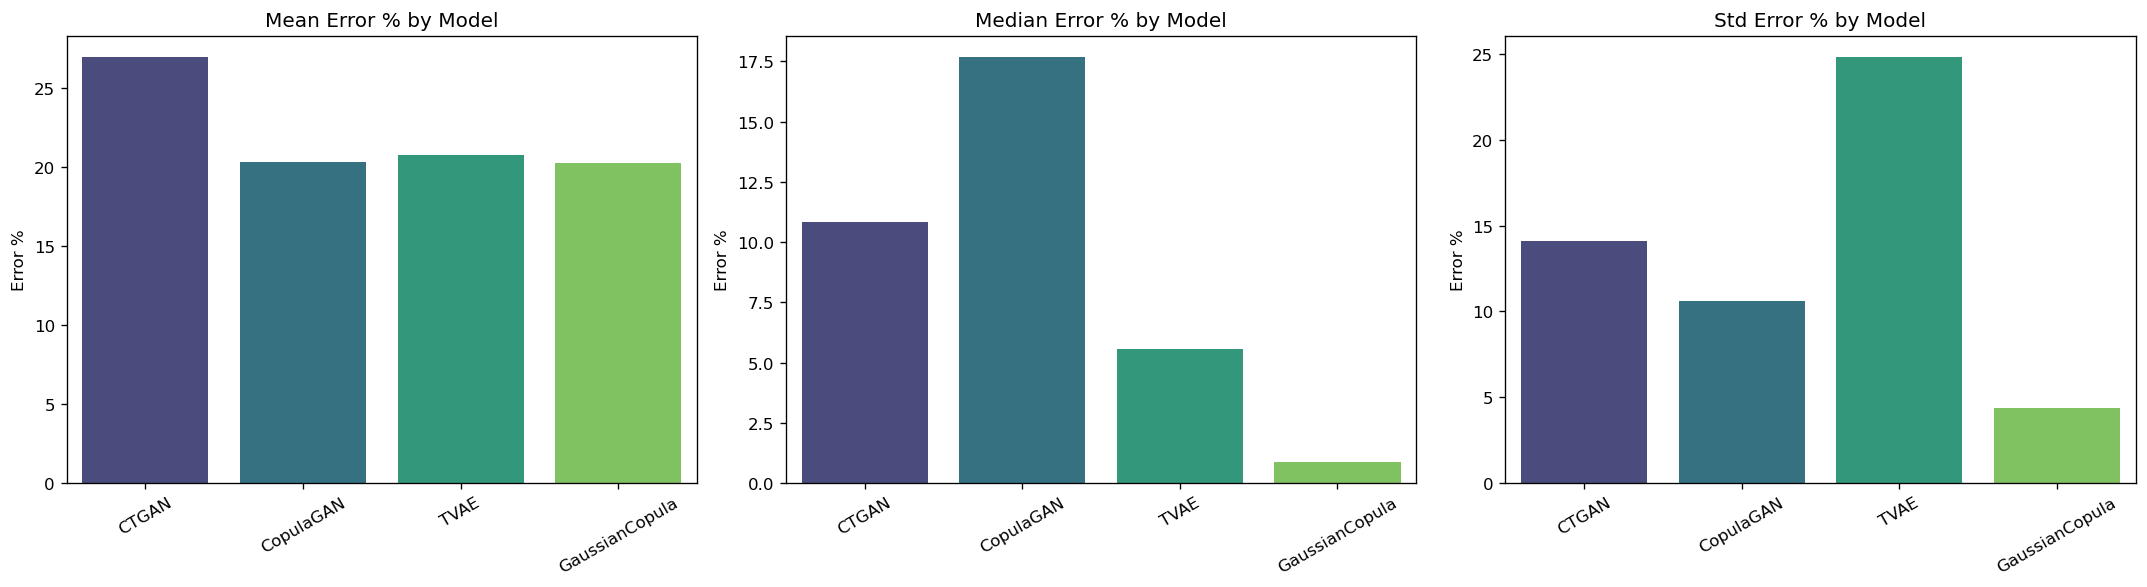

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["ID", "Diabetes_binary"]]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_df = synth_df[real_df.columns]

    real_means = real_df[num_cols].astype(np.float64).mean()
    synth_means = synth_df[num_cols].astype(np.float64).mean()

    real_stds = real_df[num_cols].astype(np.float64).std(ddof=1)
    synth_stds = synth_df[num_cols].astype(np.float64).std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    })

    feature_error_df = feature_error_df.replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True))
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()

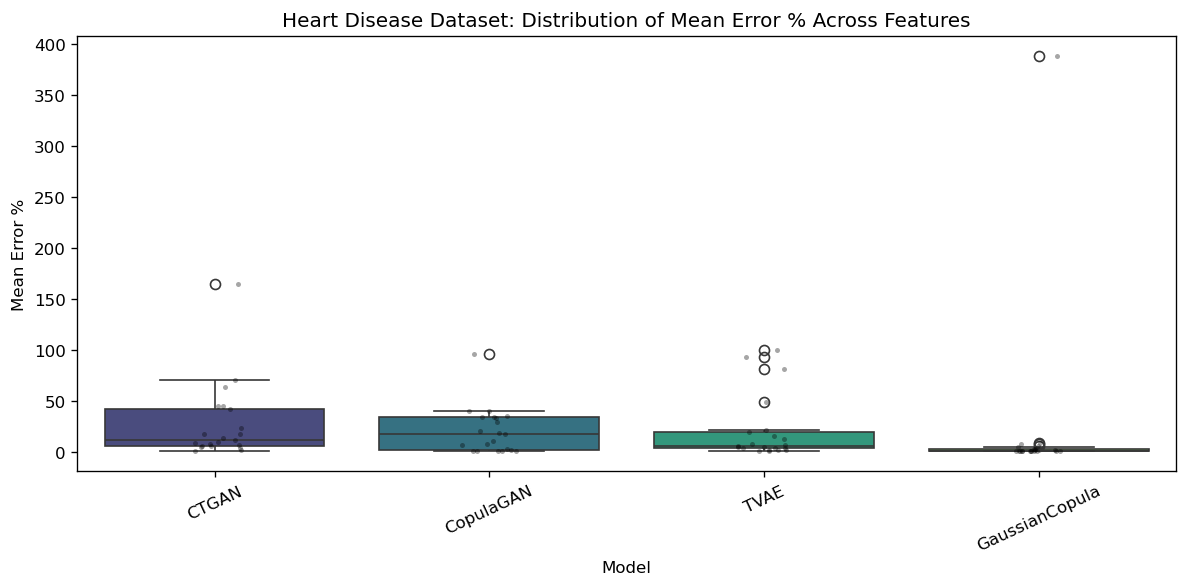

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Heart Disease Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

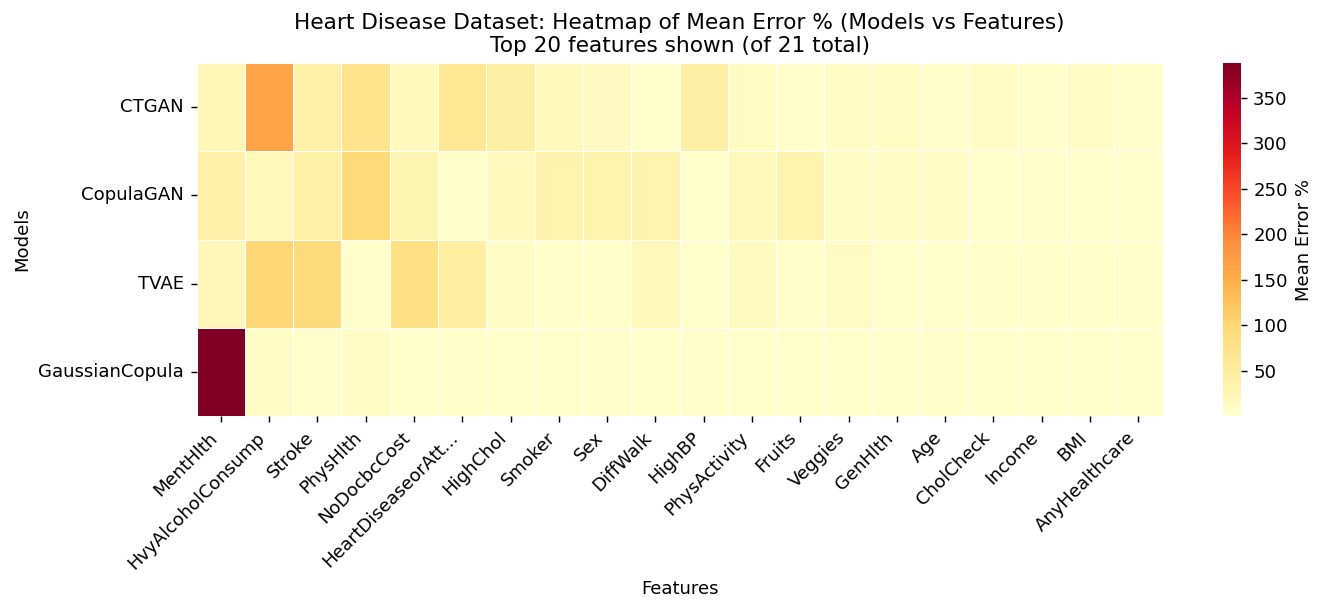

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Heart Disease Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

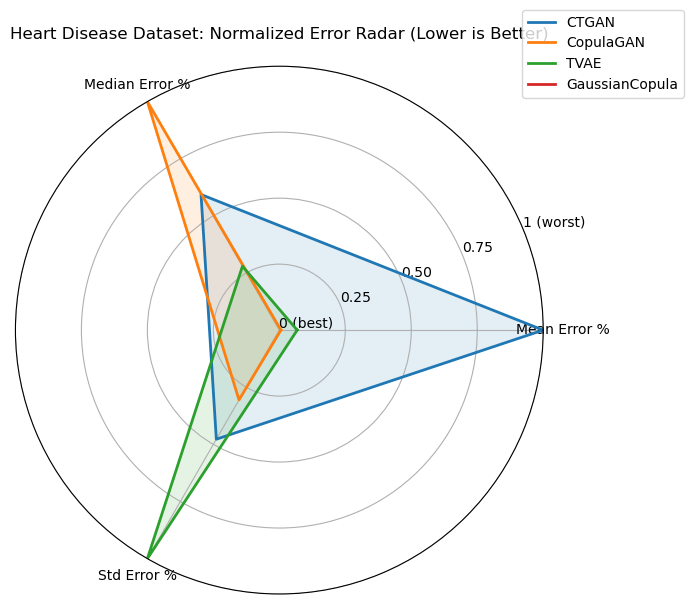

,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,1.000000,0.593340,0.477365
1,CopulaGAN,0.006031,1.000000,0.305524
2,TVAE,0.067674,0.279463,1.000000
3,GaussianCopula,0.000000,0.000000,0.000000


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metrics = ["Mean Error %", "Median Error %", "Std Error %"]
radar_df = summary_df[["Model"] + metrics].copy()

norm_df = radar_df.copy()
for m in metrics:
    mn, mx = norm_df[m].min(), norm_df[m].max()
    if mx > mn:
        norm_df[m] = (norm_df[m] - mn) / (mx - mn)
    else:
        norm_df[m] = 0.0

labels = metrics
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for _, row in norm_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0 (best)", "0.25", "0.50", "0.75", "1 (worst)"])
ax.set_title("Heart Disease Dataset: Normalized Error Radar (Lower is Better)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12))

plt.tight_layout()
plt.show()

display(norm_df)

Average absolute difference in outlier counts (Real vs Synthetic) by model:


,Model,Avg_Abs_Diff_Outlier_Count,Median_Abs_Diff_Outlier_Count,Max_Abs_Diff_Outlier_Count
0,TVAE,165.047619,126.0,651.0
1,GaussianCopula,344.285714,188.0,1472.0
2,CopulaGAN,372.714286,230.0,1369.0
3,CTGAN,438.238095,358.0,1247.0


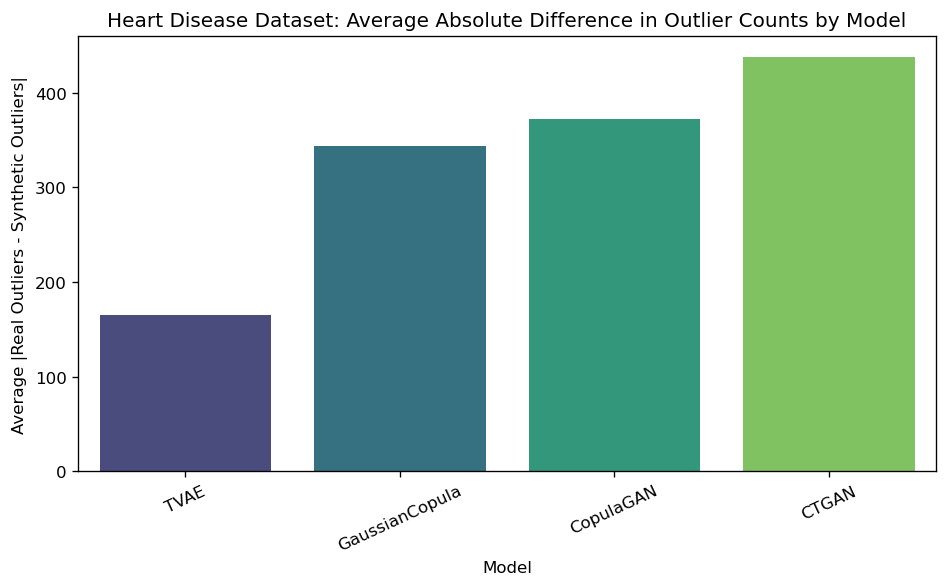

In [54]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["ID", "Diabetes_binary"]]

def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

real_outliers = {c: outlier_count_iqr(real_df[c]) for c in num_cols}

for model in model_order:
    synth_df = synthetic_datasets[model][real_df.columns].copy()
    synth_outliers = {c: outlier_count_iqr(synth_df[c]) for c in num_cols}

    feat_df = pd.DataFrame({
        "Feature": num_cols,
        "Real_Outliers": [real_outliers[c] for c in num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in num_cols]
    })
    feat_df["Abs_Diff_Outlier_Count"] = (feat_df["Real_Outliers"] - feat_df["Synthetic_Outliers"]).abs()

    feature_diff_by_model[model] = feat_df
    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].mean()),
        "Median_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].median()),
        "Max_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].max())
    })

outlier_summary_df = pd.DataFrame(rows).sort_values("Avg_Abs_Diff_Outlier_Count").reset_index(drop=True)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=outlier_summary_df, x="Model", y="Avg_Abs_Diff_Outlier_Count", palette="viridis")
plt.title("Heart Disease Dataset: Average Absolute Difference in Outlier Counts by Model")
plt.xlabel("Model")
plt.ylabel("Average |Real Outliers - Synthetic Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 6. Cosine Similarity with Hungraian Mapping

In [55]:
from numpy.linalg import norm
import numpy as np
import pandas as pd
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer

if "ctgan" not in globals():
    ctgan = CTGANSynthesizer(metadata=metadata)
    ctgan.fit(data)

if "copulagan" not in globals():
    copulagan = CopulaGANSynthesizer(metadata=metadata)
    copulagan.fit(data)

if "tvae" not in globals():
    tvae = TVAESynthesizer(metadata=metadata)
    tvae.fit(data)

if "gaussiancopula" not in globals():
    gaussiancopula = GaussianCopulaSynthesizer(metadata=metadata)
    gaussiancopula.fit(data)

synth_models = {
    "CTGAN": ctgan,
    "CopulaGAN": copulagan,
    "TVAE": tvae,
    "GaussianCopula": gaussiancopula
}

n_rows = len(data)
synthetic_data = {}
for name, synth in synth_models.items():
    synthetic_data[name] = synth.sample(num_rows=n_rows)[data.columns]

def normalize_rows(X):
    X = np.asarray(X, dtype=np.float64)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

cosine_results = {}
cosine_dfs = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["ID", "Diabetes_binary"]]

real_matrix = normalize_rows(data[num_cols].to_numpy(dtype=np.float64))

for model_name, synth_df in synthetic_data.items():
    print(f"Building cosine similarity DataFrame for {model_name}...")

    synth_matrix = normalize_rows(synth_df[num_cols].to_numpy(dtype=np.float64))
    cosine_matrix = real_matrix @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max())
    }

    print(cosine_df, "\n")

display(pd.DataFrame(cosine_results).T)

Building cosine similarity DataFrame for CTGAN...
           S1        S2        S3        S4        S5        S6        S7  \
R1   0.984911  0.936639  0.939325  0.768818  0.907393  0.965022  0.906623   
R2   0.937242  0.976675  0.991786  0.681547  0.944201  0.855354  0.936153   
R3   0.886120  0.978578  0.927832  0.616955  0.996521  0.833754  0.990311   
R4   0.895110  0.978381  0.936839  0.699642  0.991187  0.839142  0.987911   
R5   0.781771  0.651170  0.639712  0.882746  0.623070  0.826599  0.629513   
R6   0.934406  0.992469  0.979592  0.659168  0.982081  0.862812  0.989564   
R7   0.930920  0.990144  0.984893  0.667580  0.974296  0.856243  0.962665   
R8   0.935744  0.990130  0.984931  0.668066  0.966317  0.854045  0.962588   
R9   0.922942  0.990565  0.974686  0.661920  0.977031  0.851337  0.962101   
R10  0.931371  0.996226  0.981140  0.660300  0.989352  0.861088  0.984819   

           S8        S9       S10  
R1   0.931130  0.959083  0.942313  
R2   0.967776  0.988358  0.947

,avg_cosine,max_cosine
CTGAN,0.895118,1.0
CopulaGAN,0.903578,1.0
TVAE,0.907228,1.0
GaussianCopula,0.835121,1.0


In [56]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

def normalize_rows(X):
    X = np.asarray(X, dtype=np.float64)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()
    num_cols = [c for c in num_cols if c not in ["ID", "Diabetes_binary"]]

    R = real_data[num_cols].to_numpy(dtype=np.float64)
    S = synthetic_data[num_cols].to_numpy(dtype=np.float64)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = data.copy()
results = {}

for name, synth_df in synthetic_data.items():
    synth_df = synth_df[data.columns].copy()
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. R{i+1} -> S{best_indices[i]+1}   cosine similarity = {best_sims[i]:.4f}")


CTGAN - Top 10 Real -> Synthetic Matchings
01. R3368 -> S1446   cosine similarity = 1.0000
02. R1238 -> S156   cosine similarity = 1.0000
03. R2087 -> S1762   cosine similarity = 1.0000
04. R1550 -> S3150   cosine similarity = 1.0000
05. R4443 -> S4149   cosine similarity = 1.0000
06. R2780 -> S2349   cosine similarity = 1.0000
07. R4338 -> S2349   cosine similarity = 1.0000
08. R4127 -> S2349   cosine similarity = 1.0000
09. R4877 -> S91   cosine similarity = 1.0000
10. R3889 -> S326   cosine similarity = 1.0000

CopulaGAN - Top 10 Real -> Synthetic Matchings
01. R2475 -> S3152   cosine similarity = 1.0000
02. R4985 -> S3526   cosine similarity = 1.0000
03. R239 -> S2363   cosine similarity = 1.0000
04. R3032 -> S536   cosine similarity = 1.0000
05. R1825 -> S2349   cosine similarity = 1.0000
06. R3541 -> S1350   cosine similarity = 1.0000
07. R378 -> S2059   cosine similarity = 1.0000
08. R4812 -> S981   cosine similarity = 1.0000
09. R2432 -> S2373   cosine similarity = 1.0000
10. 

In [57]:
# Hungarian Mapping (Cosine) - Heart dataset setup

import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

def normalize_rows(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c not in ["ID", "Diabetes_binary"]]

    R = real_df[num_cols].to_numpy(dtype=np.float64)
    S = synth_df[num_cols].to_numpy(dtype=np.float64)
    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

real_df = data.copy()
results = {}

for name in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, numeric features excluding ID and Diabetes_binary)")
    print(f"==============================")

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")


CTGAN: Hungarian matching (cosine, numeric features excluding ID and Diabetes_binary)
Average cosine similarity (Hungarian match): 0.9931

R1550 <-> S3150   cosine similarity = 1.0000
R2087 <-> S1762   cosine similarity = 1.0000
R1762 <-> S1229   cosine similarity = 1.0000
R1325 <-> S2822   cosine similarity = 1.0000
R3462 <-> S1915   cosine similarity = 1.0000
R1169 <-> S3024   cosine similarity = 1.0000
R463 <-> S4675   cosine similarity = 1.0000
R1818 <-> S2037   cosine similarity = 1.0000
R4255 <-> S2754   cosine similarity = 1.0000
R4174 <-> S4162   cosine similarity = 0.9999

CopulaGAN: Hungarian matching (cosine, numeric features excluding ID and Diabetes_binary)
Average cosine similarity (Hungarian match): 0.9892

R4985 <-> S3526   cosine similarity = 1.0000
R239 <-> S2363   cosine similarity = 1.0000
R3541 <-> S1350   cosine similarity = 1.0000
R378 <-> S2059   cosine similarity = 1.0000
R4812 <-> S981   cosine similarity = 1.0000
R2432 <-> S2373   cosine similarity = 1.0000


In [58]:
import pandas as pd
import numpy as np

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c not in ["ID", "Diabetes_binary"]]

if "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found. Expected `synthetic_data` or `synthetic_tables`.")

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
output_file = "Hungarian_Matchings_All_Models_Heart.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results or model_name not in synth_source:
            continue

        row_ind = results[model_name]["row_ind"]
        col_ind = results[model_name]["col_ind"]

        if "similarities" in results[model_name]:
            score_key = "cosine_similarity"
            scores = results[model_name]["similarities"]
        elif "distances" in results[model_name]:
            score_key = "mahalanobis_distance"
            scores = results[model_name]["distances"]
        else:
            raise KeyError(f"No score array found for model {model_name}. Expected 'similarities' or 'distances'.")

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            score_key: scores
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name][real_df.columns].copy()
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        side_by_side.to_excel(writer, sheet_name=model_name[:31], index=False)
        combined_rows.append(side_by_side)

        summary_row = {
            "Model": model_name,
            "Num_Matches": len(scores),
            f"Avg_{score_key}": float(np.mean(scores)),
            f"Median_{score_key}": float(np.median(scores)),
            f"Min_{score_key}": float(np.min(scores)),
            f"Max_{score_key}": float(np.max(scores)),
        }
        summary_rows.append(summary_row)

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows)
        sort_col = [c for c in summary_df.columns if c.startswith("Avg_")][0]
        ascending = False if "cosine" in sort_col else True
        summary_df = summary_df.sort_values(sort_col, ascending=ascending)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)

print(f"Saved: {output_file}")
display(summary_df)

Saved: Hungarian_Matchings_All_Models_Heart.xlsx


,Model,Num_Matches,Avg_cosine_similarity,Median_cosine_similarity,Min_cosine_similarity,Max_cosine_similarity
0,CTGAN,5000,0.993087,0.996040,0.935775,1.0
2,TVAE,5000,0.992665,0.997738,0.884932,1.0
1,CopulaGAN,5000,0.989224,0.996019,0.884370,1.0
3,GaussianCopula,5000,0.920753,0.943077,0.729544,1.0


# 7. Mahalanobis distance with Hungrain Mapping  

In [59]:
import numpy as np
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["ID", "Diabetes_binary"]]

data_numeric = data[num_cols].dropna().copy()
real_matrix = data_numeric.to_numpy(dtype=np.float64)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real feature data.")
print(f"Used features: {len(num_cols)}")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")

Fitted mean and inverse covariance on real feature data.
Used features: 21
Mean shape: (21,), Inv_cov shape: (21, 21)


In [60]:
mahalanobis_results = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["ID", "Diabetes_binary"]]

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][num_cols].copy()
    synth_numeric = synth_df.to_numpy(dtype=np.float64)

    dists = mahalanobis_distances_to_distribution(synth_numeric, mu_real, inv_cov_real)

    mahalanobis_results[name] = {
        "mean": float(np.mean(dists)),
        "median": float(np.median(dists)),
        "std": float(np.std(dists)),
        "min": float(np.min(dists)),
        "max": float(np.max(dists)),
        "distances": dists,
    }

summary = pd.DataFrame({
    name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
    for name, r in mahalanobis_results.items()
}, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T

summary.index.name = "Model"
summary = summary.sort_values("mean_dist")

print("Mahalanobis distance to real distribution (lower is better):")
display(summary)

Mahalanobis distance to real distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
TVAE,3.445951,3.140849,1.067990,1.858737,7.900154
CTGAN,4.913721,4.801887,1.449530,1.900384,10.015802
CopulaGAN,5.132791,5.117155,1.539691,1.955883,10.389803
GaussianCopula,5.339559,5.325895,1.338849,2.034337,10.065275


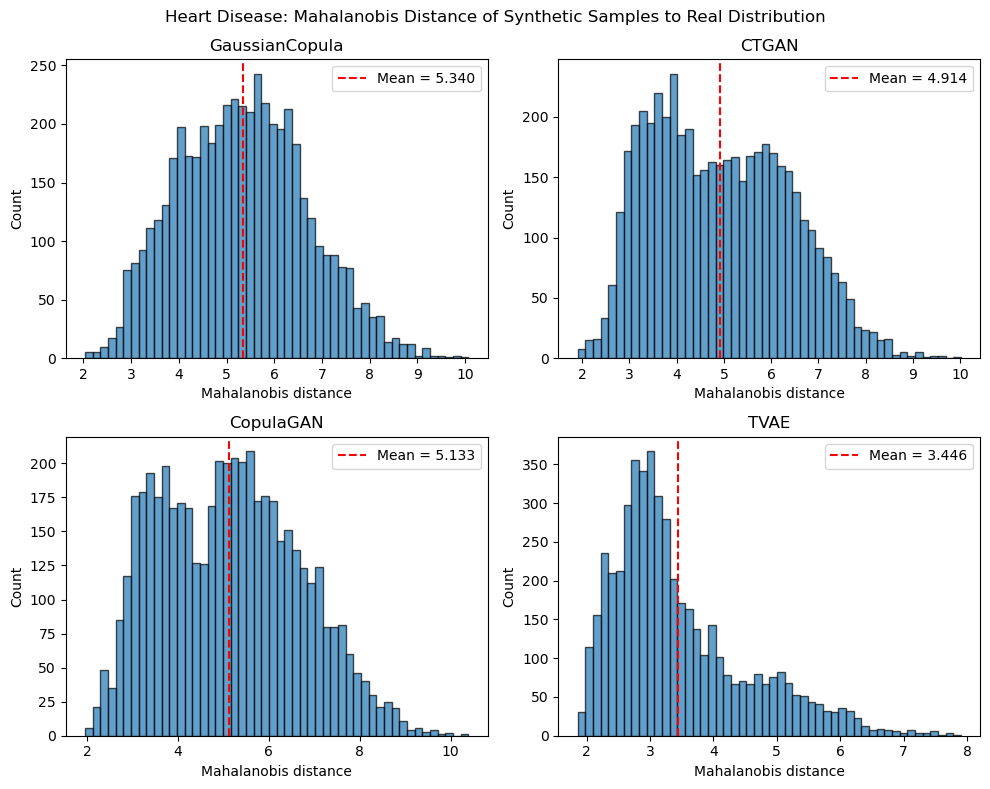

In [61]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(res["mean"], color="red", linestyle="--", label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle("Heart Disease: Mahalanobis Distance of Synthetic Samples to Real Distribution", fontsize=12)
plt.tight_layout()

ROOT = os.getcwd()
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
plt.savefig(
    os.path.join(ROOT, "figures", "mahalanobis_heart_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [62]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

hungarian_results = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["ID", "Diabetes_binary"]]

real_matrix = data[num_cols].to_numpy(dtype=np.float64)
n_samples = len(real_matrix)

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name][num_cols].to_numpy(dtype=np.float64)
    assert synth_numeric.shape[0] == n_samples, (
        f"Synthetic size {synth_numeric.shape[0]} != real size {n_samples}"
    )

    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    row_ind, col_ind = linear_sum_assignment(D)
    matched_distances = D[row_ind, col_ind]

    hungarian_results[name] = {
        "total_distance": float(matched_distances.sum()),
        "mean_distance_per_match": float(matched_distances.mean()),
        "median_distance_per_match": float(np.median(matched_distances)),
        "std_distance_per_match": float(np.std(matched_distances)),
        "max_distance_per_match": float(matched_distances.max()),
        "matched_distances": matched_distances,
        "row_ind": row_ind,
        "col_ind": col_ind,
    }

hungarian_summary = pd.DataFrame(
    {
        name: [
            r["mean_distance_per_match"],
            r["median_distance_per_match"],
            r["std_distance_per_match"],
            r["max_distance_per_match"],
        ]
        for name, r in hungarian_results.items()
    },
    index=[
        "mean_distance_per_match",
        "median_distance_per_match",
        "std_distance_per_match",
        "max_distance_per_match",
    ],
).T

hungarian_summary.index.name = "Model"
hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

print("Hungarian matching using Mahalanobis distance (lower is better):")
display(hungarian_summary)

Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match
Model,,,,
TVAE,2.801934,2.582017,1.911785,9.280514
CTGAN,3.072402,2.881077,1.708299,9.572096
CopulaGAN,3.345442,3.173248,1.891636,9.495661
GaussianCopula,3.569087,3.509104,1.560299,10.022808


In [64]:
# Fast Greedy mapping (subsampled + vectorized)

import numpy as np
import pandas as pd

def greedy_one_to_one_matching_fast(D):
    n_rows, n_cols = D.shape
    n_match = min(n_rows, n_cols)

    used_rows = np.zeros(n_rows, dtype=bool)
    used_cols = np.zeros(n_cols, dtype=bool)

    flat_order = np.argsort(D, axis=None)  # sorted candidate pairs by distance
    pairs = []

    for idx in flat_order:
        i = idx // n_cols
        j = idx % n_cols
        if not used_rows[i] and not used_cols[j]:
            used_rows[i] = True
            used_cols[j] = True
            pairs.append((i, j, float(D[i, j])))
            if len(pairs) == n_match:
                break

    distances = np.array([p[2] for p in pairs], dtype=np.float64)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

greedy_results = {}
comparison_rows = []

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["ID", "Diabetes_binary"]]

X_real_full = data[num_cols].to_numpy(dtype=np.float64)

# speed knob: reduce if still slow
MAX_ROWS = 2000
rng = np.random.default_rng(42)

if len(X_real_full) > MAX_ROWS:
    real_idx = rng.choice(len(X_real_full), size=MAX_ROWS, replace=False)
else:
    real_idx = np.arange(len(X_real_full))

X_real = X_real_full[real_idx]

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    X_synth_full = synthetic_data[name][num_cols].to_numpy(dtype=np.float64)

    if len(X_synth_full) > MAX_ROWS:
        synth_idx = rng.choice(len(X_synth_full), size=MAX_ROWS, replace=False)
    else:
        synth_idx = np.arange(len(X_synth_full))

    X_synth = X_synth_full[synth_idx]

    D = pairwise_mahalanobis(X_real, X_synth, inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    total_g, mean_g, _ = greedy_one_to_one_matching_fast(D)

    greedy_results[name] = {
        "total_distance": total_g,
        "mean_distance": mean_g
    }

    h_total = hungarian_results[name]["total_distance"]
    h_mean = hungarian_results[name]["mean_distance_per_match"]

    comparison_rows.append({
        "Model": name,
        "Rows_Used_For_Greedy": int(min(len(X_real), len(X_synth))),
        "Greedy total (sampled)": total_g,
        "Hungarian total (full)": h_total,
        "Greedy mean (sampled)": mean_g,
        "Hungarian mean (full)": h_mean,
        "Total diff": total_g - h_total,
        "Mean diff": mean_g - h_mean,
    })

greedy_summary = pd.DataFrame({
    name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
    for name in greedy_results
}, index=["total_distance", "mean_distance"]).T
greedy_summary.index.name = "Model"

print("Greedy one-to-one matching (fast sampled version):")
display(greedy_summary)

print("\nComparison table:")
comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison_df)

Greedy one-to-one matching (fast sampled version):


,total_distance,mean_distance
Model,,
GaussianCopula,7912.218349,3.956109
CTGAN,6892.603964,3.446302
CopulaGAN,7577.734037,3.788867
TVAE,6074.399439,3.037200



Comparison table:


,Rows_Used_For_Greedy,Greedy total (sampled),Hungarian total (full),Greedy mean (sampled),Hungarian mean (full),Total diff,Mean diff
Model,,,,,,,
GaussianCopula,2000,7912.218349,17845.436701,3.956109,3.569087,-9933.218352,0.387022
CTGAN,2000,6892.603964,15362.008396,3.446302,3.072402,-8469.404433,0.373900
CopulaGAN,2000,7577.734037,16727.210319,3.788867,3.345442,-9149.476282,0.443425
TVAE,2000,6074.399439,14009.670965,3.037200,2.801934,-7935.271526,0.235266


In [65]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=np.float64)
    S = synth_df[feature_cols].to_numpy(dtype=np.float64)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=np.float64), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = data.copy()

feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c not in ["ID", "Diabetes_binary"]]
print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=np.float64)
mu_real = X_real.mean(axis=0)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")

Using numeric non-target features: 21
GaussianCopula: avg matched Mahalanobis distance = 3.5691
CTGAN: avg matched Mahalanobis distance = 3.0724
CopulaGAN: avg matched Mahalanobis distance = 3.3454
TVAE: avg matched Mahalanobis distance = 2.8019


In [66]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=np.float64)
    S = synth_df[feature_cols].to_numpy(dtype=np.float64)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=np.float64), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = data.copy()

feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c not in ["ID", "Diabetes_binary"]]
print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=np.float64)
mu_real = X_real.mean(axis=0)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")

Using numeric non-target features: 21
GaussianCopula: avg matched Mahalanobis distance = 3.5691
CTGAN: avg matched Mahalanobis distance = 3.0724
CopulaGAN: avg matched Mahalanobis distance = 3.3454
TVAE: avg matched Mahalanobis distance = 2.8019


In [67]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c not in ["ID", "Diabetes_binary"]]

real_df = data.copy()
X_real = real_df[feature_cols].to_numpy(dtype=np.float64)

cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

for model_name in model_order:
    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_synth = synth_df[feature_cols].to_numpy(dtype=np.float64)

    D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    if D.shape[0] <= D.shape[1]:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    r_to_match = {r: (s, d) for r, s, d in zip(row_ind, col_ind, dists)}

    print(f"\n{model_name} - Hungarian mappings for R1 to R20:")
    for r in range(20):
        if r in r_to_match:
            s, dist = r_to_match[r]
            print(f"R{r+1} -> S{s+1}   distance = {dist:.4f}")
        else:
            print(f"R{r+1} -> No match found")


CTGAN - Hungarian mappings for R1 to R20:
R1 -> S2478   distance = 3.7904
R2 -> S4031   distance = 1.3676
R3 -> S3384   distance = 4.0378
R4 -> S3925   distance = 3.0625
R5 -> S3172   distance = 3.9798
R6 -> S3499   distance = 2.8813
R7 -> S2706   distance = 1.2170
R8 -> S2664   distance = 6.0674
R9 -> S933   distance = 0.3847
R10 -> S4612   distance = 1.6773
R11 -> S4889   distance = 1.3171
R12 -> S3981   distance = 5.9575
R13 -> S2693   distance = 1.0166
R14 -> S4672   distance = 3.7742
R15 -> S4093   distance = 4.1068
R16 -> S4930   distance = 2.1966
R17 -> S236   distance = 3.5105
R18 -> S3710   distance = 4.1290
R19 -> S4229   distance = 2.5378
R20 -> S774   distance = 0.6771

CopulaGAN - Hungarian mappings for R1 to R20:
R1 -> S4029   distance = 4.4514
R2 -> S3467   distance = 1.5728
R3 -> S3058   distance = 7.7255
R4 -> S4506   distance = 1.4253
R5 -> S4503   distance = 5.0129
R6 -> S2524   distance = 4.6888
R7 -> S1171   distance = 6.1111
R8 -> S1267   distance = 3.4513
R9 -> 

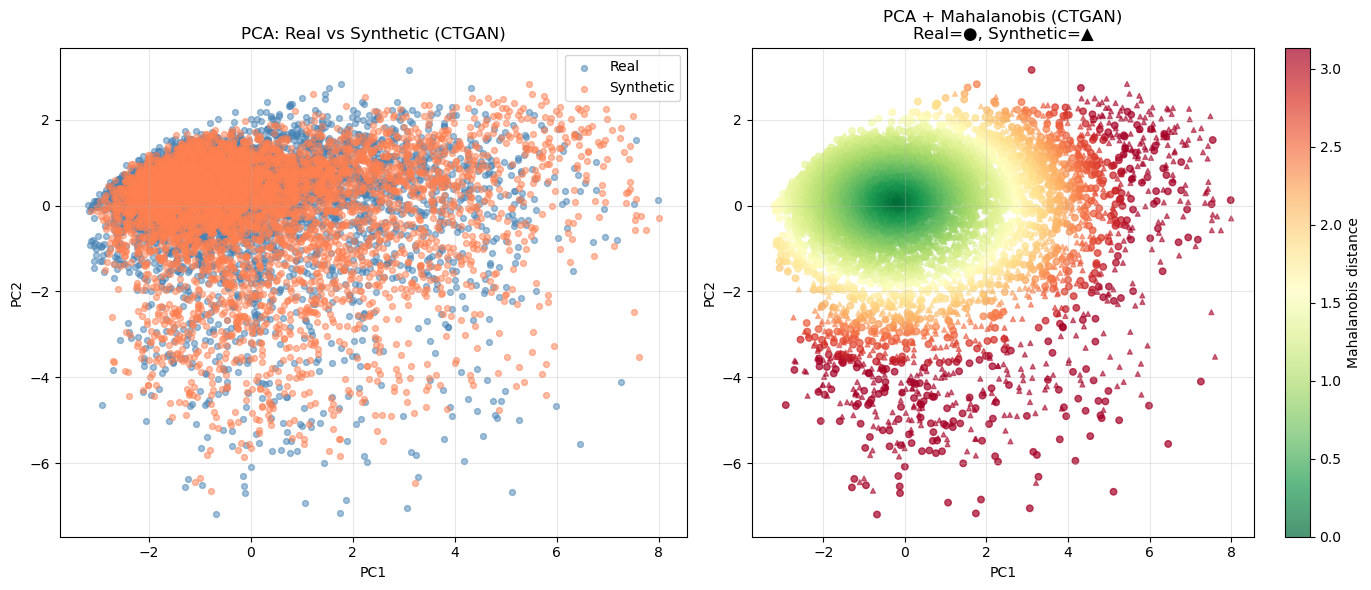

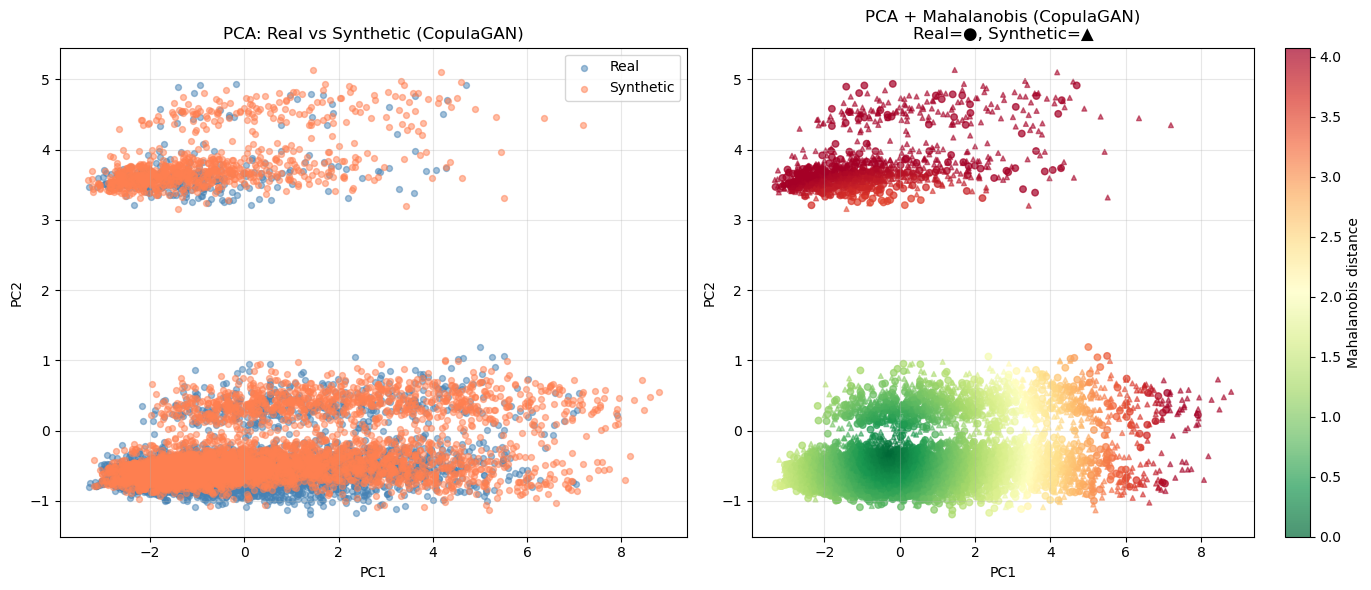

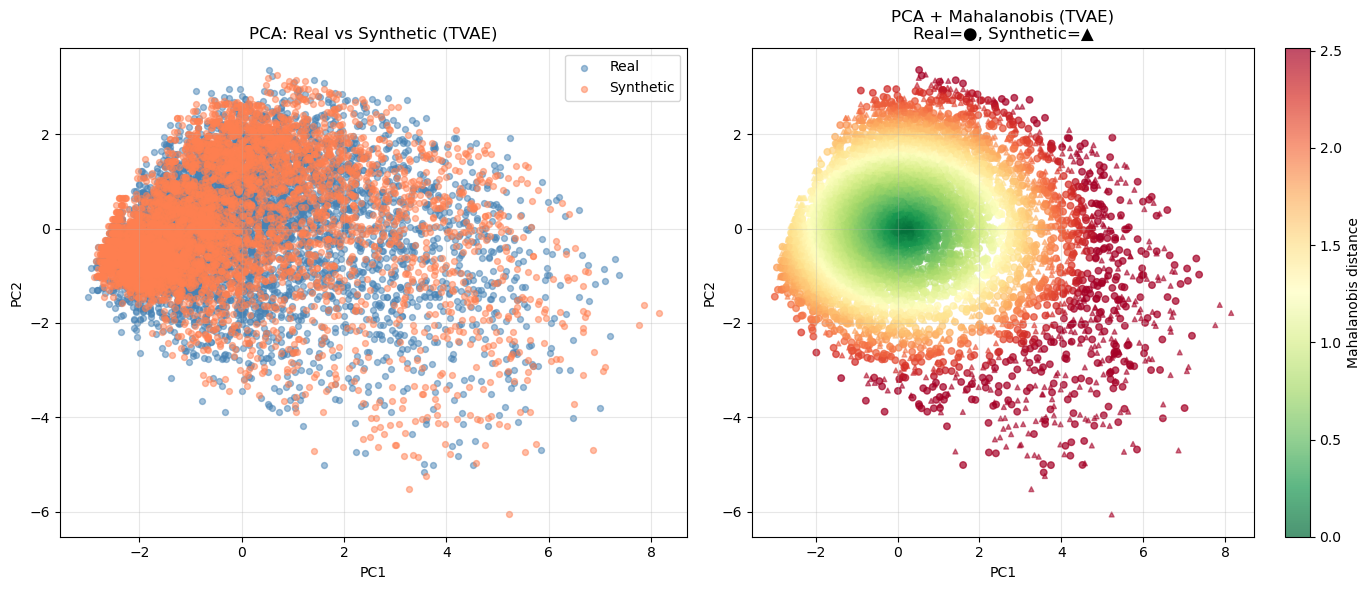

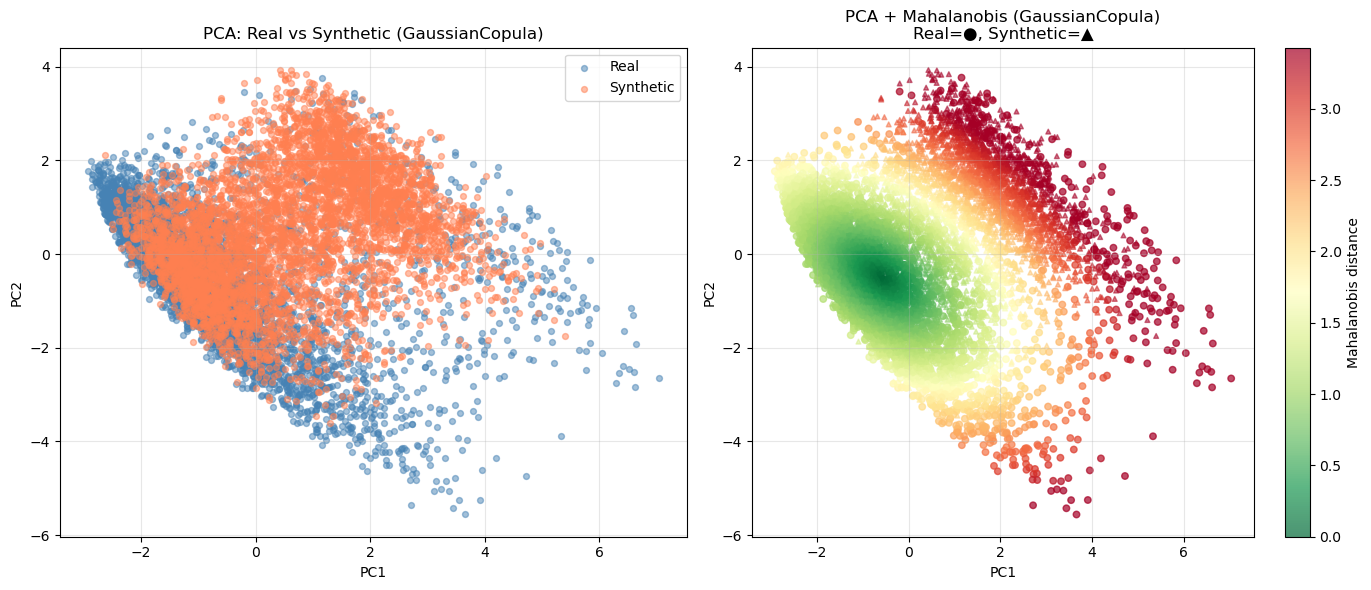

,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
0,CTGAN,1.161891,1.294559,0.132668
2,TVAE,1.249207,1.333968,0.084761
1,CopulaGAN,1.072542,1.599497,0.526955
3,GaussianCopula,1.163830,1.744718,0.580888


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c not in ["ID", "Diabetes_binary"]]

X_r = real_df[feature_cols].to_numpy(dtype=np.float64)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synthetic_data:
        print(f"{model_name} not found in synthetic_data, skipping.")
        continue

    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_s = synth_df[feature_cols].to_numpy(dtype=np.float64)
    X_s_s = scaler.transform(X_s)

    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = np.linalg.pinv(cov_z + reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
display(summary_df)

In [69]:
# print results on excel sheets

import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "Hungarian_Mahalanobis_Four_Models_Heart.xlsx"
):
    model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                continue

            synth_df = synthetic_data[model_name].copy()
            synth_df = synth_df[real_df.columns]

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["distances"]
            elif "selected_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["selected_distances"]
            elif "matched_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["matched_distances"]
            else:
                raise KeyError(f"No distance array found for {model_name}")

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Dataset": "Heart",
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                for c in num_cols:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            sheet_name = f"Heart_{model_name}"[:31]
            matched_df.to_excel(writer, sheet_name=sheet_name, index=False)

            summary_rows.append({
                "Dataset": "Heart",
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name="Heart_Summary", index=False)

    print(f"Excel file created: {filename}")

# ---- Run ----
real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["ID", "Diabetes_binary"]]

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_data=synthetic_data,
    hungarian_results=hungarian_results,
    num_cols=num_cols,
    filename="Hungarian_Mahalanobis_Four_Models_Heart.xlsx"
)

Excel file created: Hungarian_Mahalanobis_Four_Models_Heart.xlsx


# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [70]:
# MIA with ML regression model

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample(model, X, y, eps=1e-15):
    proba = model.predict_proba(X)
    n = len(y)
    y_idx = y.astype(int).clip(0, proba.shape[1] - 1)
    p_true = proba[np.arange(n), y_idx] + eps
    return -np.log(p_true)

def privacy_metrics_mia(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    model.fit(X_train_s, y_train)

    loss_train = model_loss_per_sample(model, X_train_s, y_train)
    loss_test = model_loss_per_sample(model, X_test_s, y_test)

    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx_fpr_001 = np.searchsorted(fpr, 0.01, side="right") - 1
    idx_fpr_001 = max(0, idx_fpr_001)
    tpr_at_fpr_001 = tpr[idx_fpr_001] if idx_fpr_001 < len(tpr) else float("nan")

    return {"AUC": auc, "Advantage": advantage, "TPR_at_FPR_001": tpr_at_fpr_001}

target_col = "Diabetes_binary"
feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c not in ["ID", target_col]]

real_df = data.copy()
synth_df = synthetic_data["GaussianCopula"][real_df.columns].copy()

X_train = real_df[feature_cols].to_numpy(dtype=np.float64)
y_train = real_df[target_col].to_numpy(dtype=int)

X_test = synth_df[feature_cols].to_numpy(dtype=np.float64)
y_test = synth_df[target_col].to_numpy(dtype=int)

model = LogisticRegression(max_iter=1000, random_state=42)
metrics = privacy_metrics_mia(model, X_train, y_train, X_test, y_test)
print(metrics)

{'AUC': 0.53600778, 'Advantage': 0.0922, 'TPR_at_FPR_001': 0.0226}


In [71]:
# MIA with Mahalanobis

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c not in ["ID", "Diabetes_binary"]]
X_train = data[feature_cols].to_numpy(dtype=np.float64)

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
rows = []

for model_name in model_order:
    X_test = synthetic_data[model_name][feature_cols].to_numpy(dtype=np.float64)
    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

comparison_df = pd.DataFrame(rows)[
    ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
].sort_values("AUC", ascending=False).reset_index(drop=True)

print("MIA (Mahalanobis) comparison across 4 synthetic models:")
display(comparison_df)

MIA (Mahalanobis) comparison across 4 synthetic models:


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,GaussianCopula,0.700504,0.3118,0.0982,4.357475,5.339573
1,CopulaGAN,0.646885,0.2174,0.0360,4.357475,5.132809
2,CTGAN,0.613632,0.1608,0.0424,4.357475,4.913739
3,TVAE,0.298611,0.0000,0.0012,4.357475,3.445957
